In [8]:
# This notebook is for discrete binning HOF fraction plots + models from Nadler 2025

# import + def functions 
import pynbody, numpy as np,matplotlib.pyplot as plt
import tarfile, zipfile

# compute discrete HOF fraction
def discrete_HOF(masses,Nstar,bins):
    # create arrays to store data
    n_bins = len(bins - 1)
    occ_frac_data = np.zeros(n_bins)
    DM_mass_data = np.zeros(n_bins)
    
    # assign each halo a bin index
    bin_idx = np.digitize(masses, bins)
    
    for i in range(1,n_bins):
        current_bin = bin_idx == i
        bin_masses = masses[current_bin]
        bin_Nstar = Nstars[current_bin]

        total = len(bin_masses)
        occ = np.sum(bin_Nstar > 0)
        occ_frac = occ/total
        print(f'[DM sim {sim}: bin {i}] {occ}/{total} = {occ_frac}')

        med_DM_mass = np.median(bin_masses)
        occ_frac_data[i] = occ_frac
        DM_mass_data[i] = med_DM_mass

    return occ_frac_data, DM_mass_data

[DM sim 0: bin 1] 1/7271 = 0.00013753266400770182
[DM sim 0: bin 2] 2/305 = 0.006557377049180328
[DM sim 0: bin 3] 1/42 = 0.023809523809523808
[DM sim 0: bin 4] 4/4 = 1.0
[DM sim 0: bin 5] 5/5 = 1.0
------------------------------------------
[DM sim 1: bin 1] 0/18247 = 0.0
[DM sim 1: bin 2] 0/1096 = 0.0
[DM sim 1: bin 3] 3/143 = 0.02097902097902098
[DM sim 1: bin 4] 7/12 = 0.5833333333333334
[DM sim 1: bin 5] 2/2 = 1.0
------------------------------------------
[DM sim 2: bin 1] 0/18373 = 0.0
[DM sim 2: bin 2] 0/955 = 0.0
[DM sim 2: bin 3] 4/150 = 0.02666666666666667
[DM sim 2: bin 4] 5/13 = 0.38461538461538464
[DM sim 2: bin 5] 2/3 = 0.6666666666666666
------------------------------------------
[DM sim 3: bin 1] 1/20111 = 4.972403162448411e-05
[DM sim 3: bin 2] 1/1012 = 0.0009881422924901185
[DM sim 3: bin 3] 12/147 = 0.08163265306122448
[DM sim 3: bin 4] 9/20 = 0.45
[DM sim 3: bin 5] 7/7 = 1.0
------------------------------------------
[DM sim 4: bin 1] 1/5943 = 0.0001682651859330304

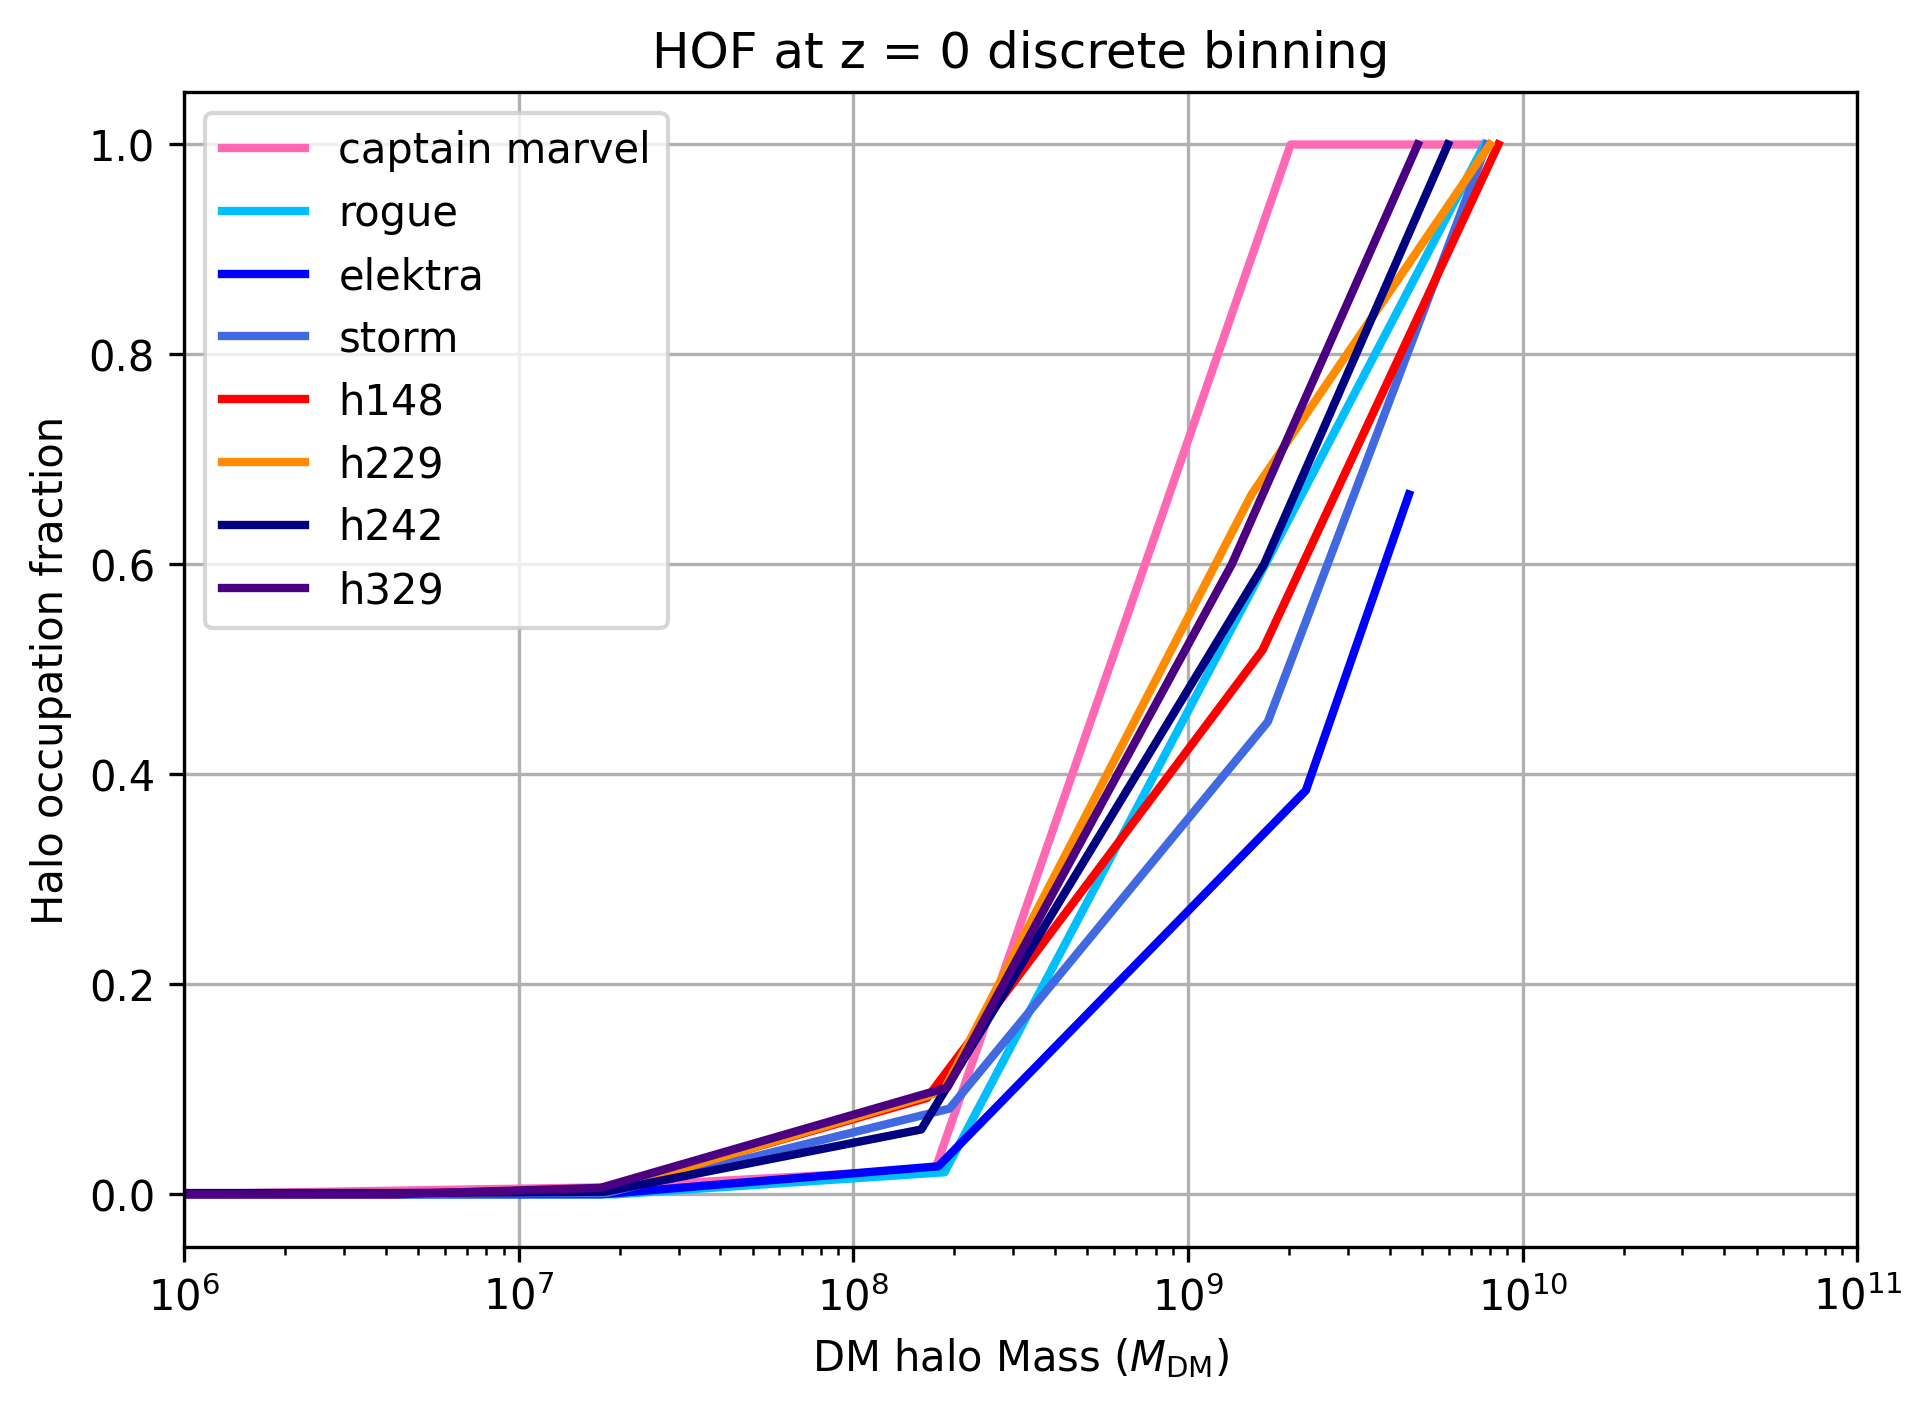

[DM sim 0: bin 1] 1/7271 = 0.00013753266400770182
[DM sim 0: bin 2] 2/305 = 0.006557377049180328
[DM sim 0: bin 3] 1/42 = 0.023809523809523808
[DM sim 0: bin 4] 4/4 = 1.0
[DM sim 0: bin 5] 5/5 = 1.0
[DM sim 1: bin 1] 2/18249 = 0.00010959504630390706
[DM sim 1: bin 2] 0/1096 = 0.0
[DM sim 1: bin 3] 3/143 = 0.02097902097902098
[DM sim 1: bin 4] 7/12 = 0.5833333333333334
[DM sim 1: bin 5] 2/2 = 1.0
[DM sim 2: bin 1] 0/18373 = 0.0
[DM sim 2: bin 2] 0/955 = 0.0
[DM sim 2: bin 3] 4/150 = 0.02666666666666667
[DM sim 2: bin 4] 5/13 = 0.38461538461538464
[DM sim 2: bin 5] 2/3 = 0.6666666666666666
[DM sim 3: bin 1] 4/20114 = 0.00019886646117132345
[DM sim 3: bin 2] 1/1012 = 0.0009881422924901185
[DM sim 3: bin 3] 12/147 = 0.08163265306122448
[DM sim 3: bin 4] 9/20 = 0.45
[DM sim 3: bin 5] 7/7 = 1.0
[DM sim 4: bin 1] 1/5943 = 0.00016826518593303046
[DM sim 4: bin 2] 12/2216 = 0.005415162454873646
[DM sim 4: bin 3] 20/218 = 0.09174311926605505
[DM sim 4: bin 4] 14/27 = 0.5185185185185185
[DM sim 4

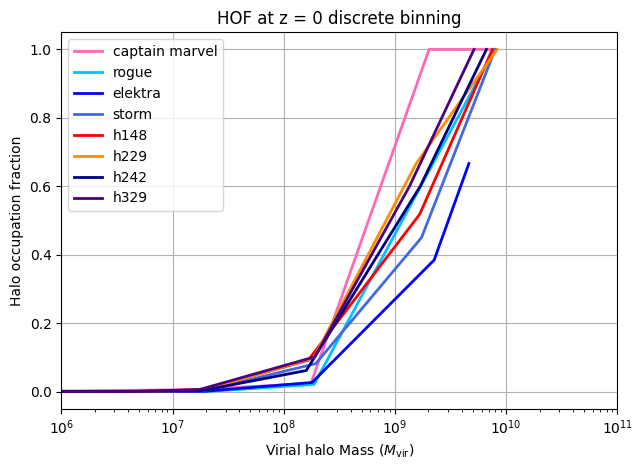

In [9]:
# HOF vs DM mass and Mvir at z=0 Marvel + h sims DISCRETE binning 
"""
Cummulative HOF at z = 0
Data: Marvel and h stat files
Discrete binning: hand selected bins to show increasing occ_frac
4/28/25
edited 5/26,6/26
"""

# open all sim data files for M200, z=0 
cptmarvel = "Stat_Files/cptmarvel.cosmo25cmb.4096g5HbwK1BH/cptmarvel.cosmo25cmb.4096g5HbwK1BH.004096/cptmarvel.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
cptm = np.genfromtxt(cptmarvel, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

rogue = "Stat_Files/rogue.cosmo25cmb.4096g5HbwK1BH/rogue.cosmo25cmb.4096g5HbwK1BH.004096/rogue.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
rg = np.genfromtxt(rogue, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

elektra = "Stat_Files/elektra.cosmo25cmb.4096g5HbwK1BH/elektra.cosmo25cmb.4096g5HbwK1BH.004096/elektra.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
elk = np.genfromtxt(elektra, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

storm = "Stat_Files/storm.cosmo25cmb.4096g5HbwK1BH/storm.cosmo25cmb.4096g5HbwK1BH.004096/storm.cosmo25cmb.4096g5HbwK1BH.004096.amiga.stat"
stm = np.genfromtxt(storm, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h148 = "Stat_Files/h148.cosmo50PLK.3072g3HbwK1BH/h148.cosmo50PLK.3072g3HbwK1BH.004096/h148.cosmo50PLK.3072g3HbwK1BH.004096.amiga.stat"
h1 = np.genfromtxt(h148, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h229 = "Stat_Files/h229.cosmo50PLK.3072gst5HbwK1BH/h229.cosmo50PLK.3072gst5HbwK1BH.004096/h229.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h2 = np.genfromtxt(h229, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h242 = "Stat_Files/h242.cosmo50PLK.3072gst5HbwK1BH/h242.cosmo50PLK.3072gst5HbwK1BH.004096/h242.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h3 = np.genfromtxt(h242, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

h329 = "Stat_Files/h329.cosmo50PLK.3072gst5HbwK1BH/h329.cosmo50PLK.3072gst5HbwK1BH.004096/h329.cosmo50PLK.3072gst5HbwK1BH.004096.amiga.stat"
h4 = np.genfromtxt(h329, skip_header = 2, dtype=float, encoding='utf-8', usecols = (3,5,9))

# reconfigure data by type rather than by sim
Nstar = [ (cptm[:,0]), (rg[:,0]), (elk[:,0]), (stm[:,0]), (h1[:,0]), (h2[:,0]), (h3[:,0]), (h4[:,0])]

vir_mass = [ (cptm[:,1]), (rg[:,1]), (elk[:,1]), (stm[:,1]), (h1[:,1]), (h2[:,1]), (h3[:,1]), (h4[:,1])]

DM_mass = [ (cptm[:,2]), (rg[:,2]), (elk[:,2]), (stm[:,2]), (h1[:,2]), (h2[:,2]), (h3[:,2]), (h4[:,2])]

n_sims = 8

# make plot 
plt.figure(dpi = 300)
colors = np.array(['hotpink', 'deepskyblue', 'blue', 'royalblue', 'red', 'darkorange', 'navy', 'indigo'])
labels = np.array(['captain marvel', 'rogue', 'elektra', 'storm', 'h148', 'h229', 'h242', 'h329', 'h516'])

bins = np.array([1e5,1e7,1e8,1e9,4e9,1e10])

# loop through each simulation to make DM mass plot
for sim in range(n_sims):

    # get data for this sim
    masses = DM_mass[sim]
    Nstars = Nstar[sim]

    # ensure sorted from smallest to largest DM mass
    idx = np.argsort(masses)
    masses = masses[idx]
    Nstars = Nstars[idx]

    occ_frac_data,DM_mass_data = discrete_HOF(masses,Nstars,bins)
    print('------------------------------------------')
    plt.semilogx(DM_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim], label = labels[sim])

plt.xlabel(r'DM halo Mass ($M_\text{DM}$)')
plt.ylabel('Halo occupation fraction')
plt.title('HOF at z = 0 discrete binning')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(1e6,1e11)
plt.show()

# loop through each simulation to make virial mass plot
for sim in range(n_sims):

    # get data for this sim
    masses = vir_mass[sim]
    Nstars = Nstar[sim]

    # ensure sorted from smallest to largest DM mass
    idx = np.argsort(masses)
    masses = masses[idx]
    Nstars = Nstars[idx]

    occ_frac_data,vir_mass_data = discrete_HOF(masses,Nstars,bins)

    plt.semilogx(vir_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim], label = labels[sim])

plt.xlabel(r'Virial halo Mass ($M_{\mathrm{vir}}$)')
plt.ylabel('Halo occupation fraction')
plt.title('HOF at z = 0 discrete binning')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.xlim(1e6,1e11)
plt.show()

[DM sim 7: bin 1] 0/175 = 0.0
[DM sim 7: bin 2] 1/280 = 0.0035714285714285713
[DM sim 7: bin 3] 7/38 = 0.18421052631578946
[DM sim 7: bin 4] 9/9 = 1.0
[DM sim 7: bin 5] 1/1 = 1.0
[DM sim 7: bin 1] 1/590 = 0.001694915254237288
[DM sim 7: bin 2] 0/983 = 0.0
[DM sim 7: bin 3] 10/128 = 0.078125
[DM sim 7: bin 4] 8/12 = 0.6666666666666666
[DM sim 7: bin 5] 4/4 = 1.0
[DM sim 7: bin 1] 1/541 = 0.0018484288354898336
[DM sim 7: bin 2] 0/1013 = 0.0
[DM sim 7: bin 3] 12/105 = 0.11428571428571428
[DM sim 7: bin 4] 16/16 = 1.0
[DM sim 7: bin 5] 1/1 = 1.0
[DM sim 7: bin 1] 1/729 = 0.0013717421124828531
[DM sim 7: bin 2] 2/1091 = 0.0018331805682859762
[DM sim 7: bin 3] 27/146 = 0.18493150684931506
[DM sim 7: bin 4] 20/20 = 1.0
[DM sim 7: bin 5] 4/4 = 1.0


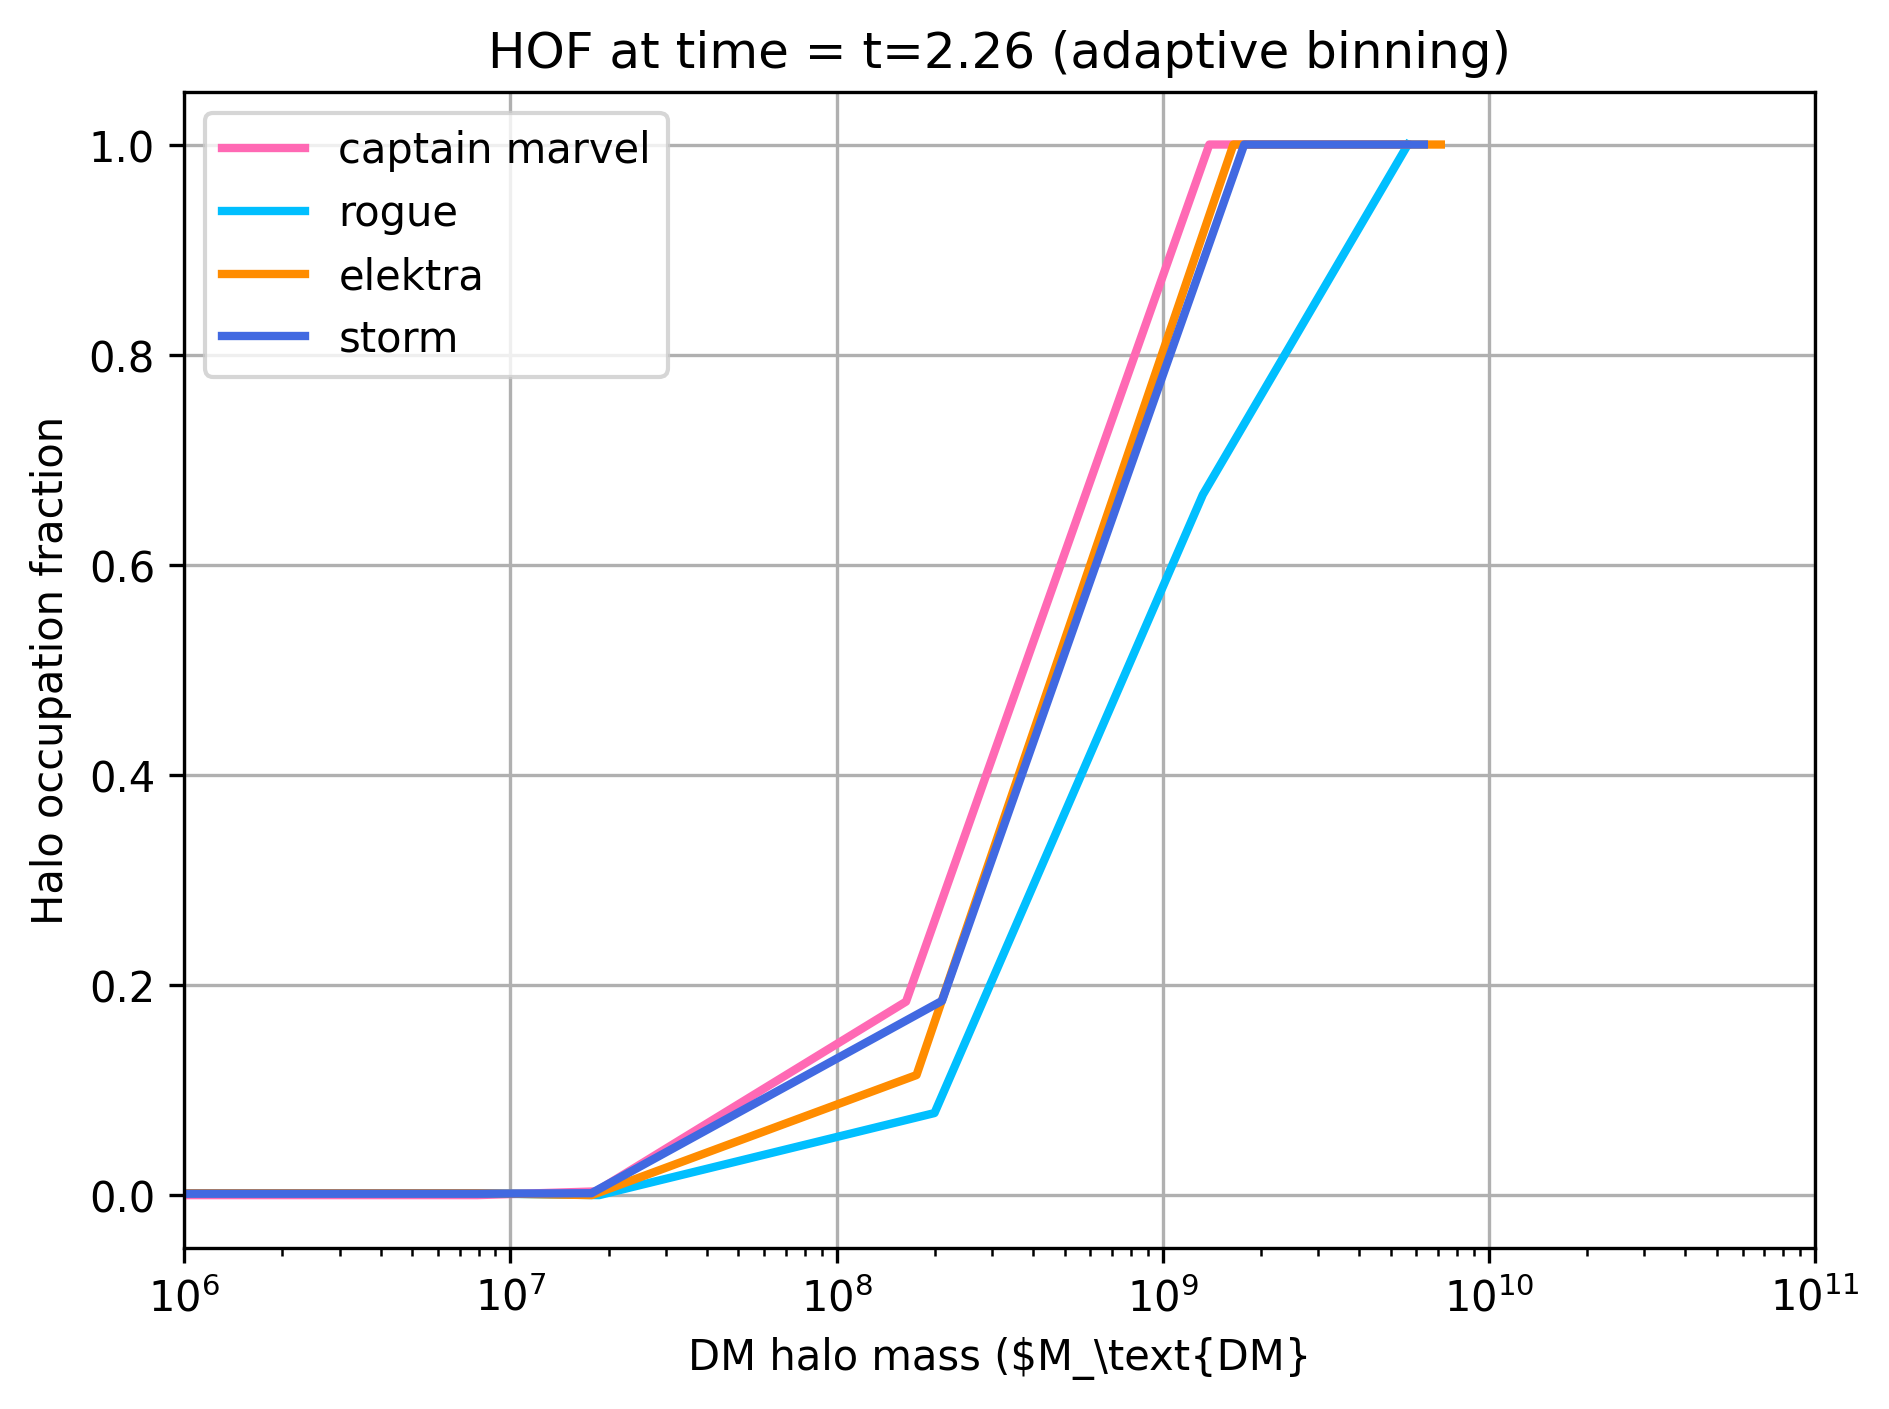

[DM sim 7: bin 1] 0/201 = 0.0
[DM sim 7: bin 2] 1/289 = 0.0034602076124567475
[DM sim 7: bin 3] 7/40 = 0.175
[DM sim 7: bin 4] 8/8 = 1.0
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 1/618 = 0.0016181229773462784
[DM sim 7: bin 2] 0/1008 = 0.0
[DM sim 7: bin 3] 9/140 = 0.06428571428571428
[DM sim 7: bin 4] 9/12 = 0.75
[DM sim 7: bin 5] 4/4 = 1.0
[DM sim 7: bin 1] 1/506 = 0.001976284584980237
[DM sim 7: bin 2] 2/1079 = 0.0018535681186283596
[DM sim 7: bin 3] 9/109 = 0.08256880733944955
[DM sim 7: bin 4] 14/16 = 0.875
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 1/710 = 0.0014084507042253522
[DM sim 7: bin 2] 1/1145 = 0.0008733624454148472
[DM sim 7: bin 3] 23/156 = 0.14743589743589744
[DM sim 7: bin 4] 20/22 = 0.9090909090909091
[DM sim 7: bin 5] 4/4 = 1.0


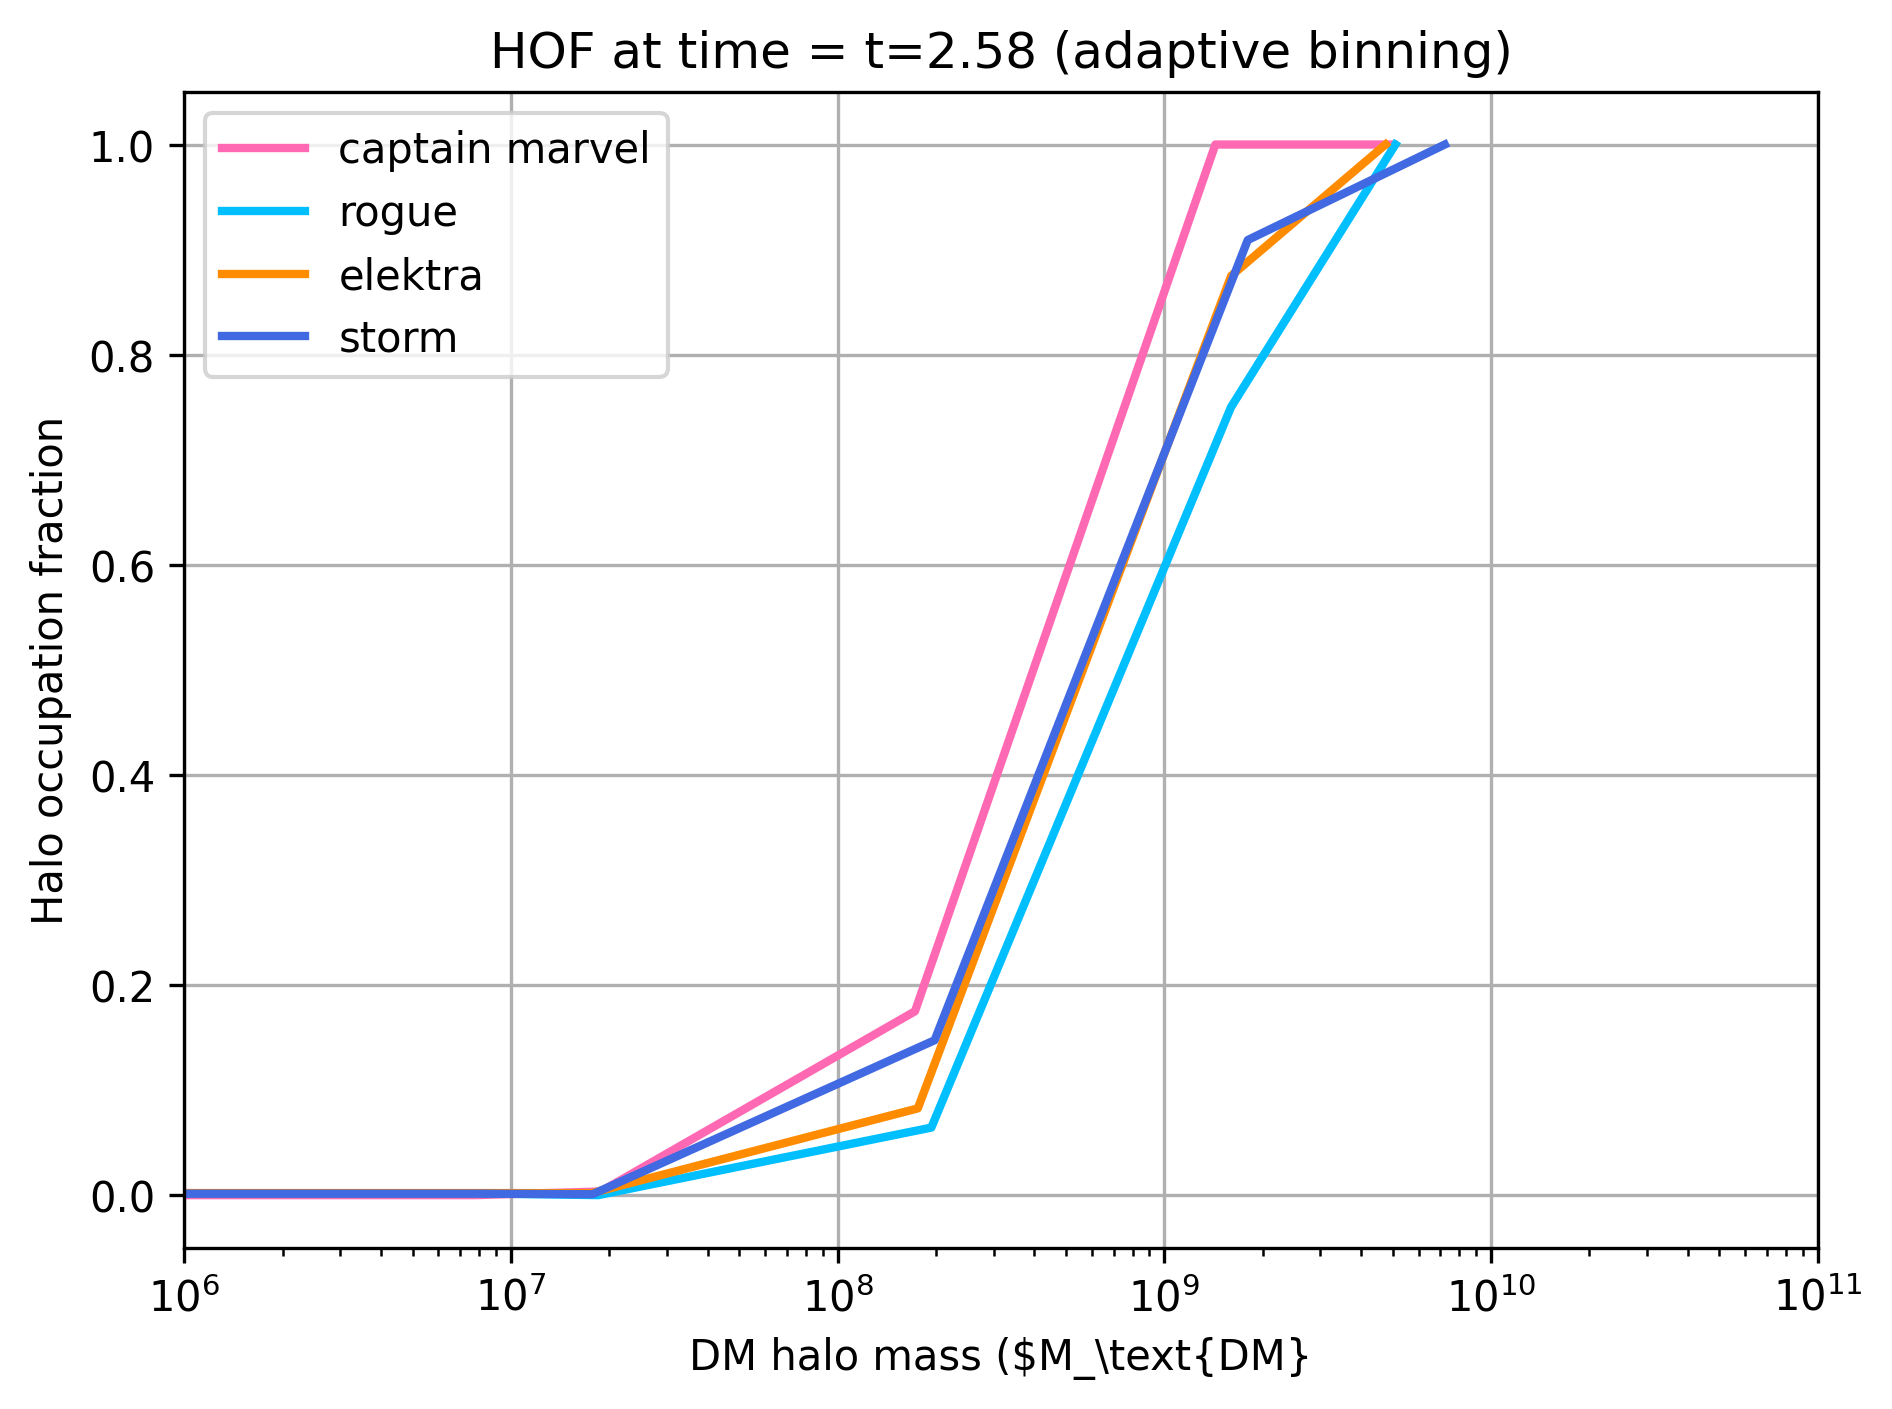

[DM sim 7: bin 1] 0/207 = 0.0
[DM sim 7: bin 2] 0/304 = 0.0
[DM sim 7: bin 3] 8/55 = 0.14545454545454545
[DM sim 7: bin 4] 6/6 = 1.0
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 0/611 = 0.0
[DM sim 7: bin 2] 0/1100 = 0.0
[DM sim 7: bin 3] 8/150 = 0.05333333333333334
[DM sim 7: bin 4] 6/16 = 0.375
[DM sim 7: bin 5] 6/6 = 1.0
[DM sim 7: bin 1] 2/588 = 0.003401360544217687
[DM sim 7: bin 2] 1/1091 = 0.0009165902841429881
[DM sim 7: bin 3] 7/130 = 0.05384615384615385
[DM sim 7: bin 4] 8/9 = 0.8888888888888888
[DM sim 7: bin 5] 7/7 = 1.0
[DM sim 7: bin 1] 0/746 = 0.0
[DM sim 7: bin 2] 2/1236 = 0.0016181229773462784
[DM sim 7: bin 3] 18/158 = 0.11392405063291139
[DM sim 7: bin 4] 16/23 = 0.6956521739130435
[DM sim 7: bin 5] 8/8 = 1.0


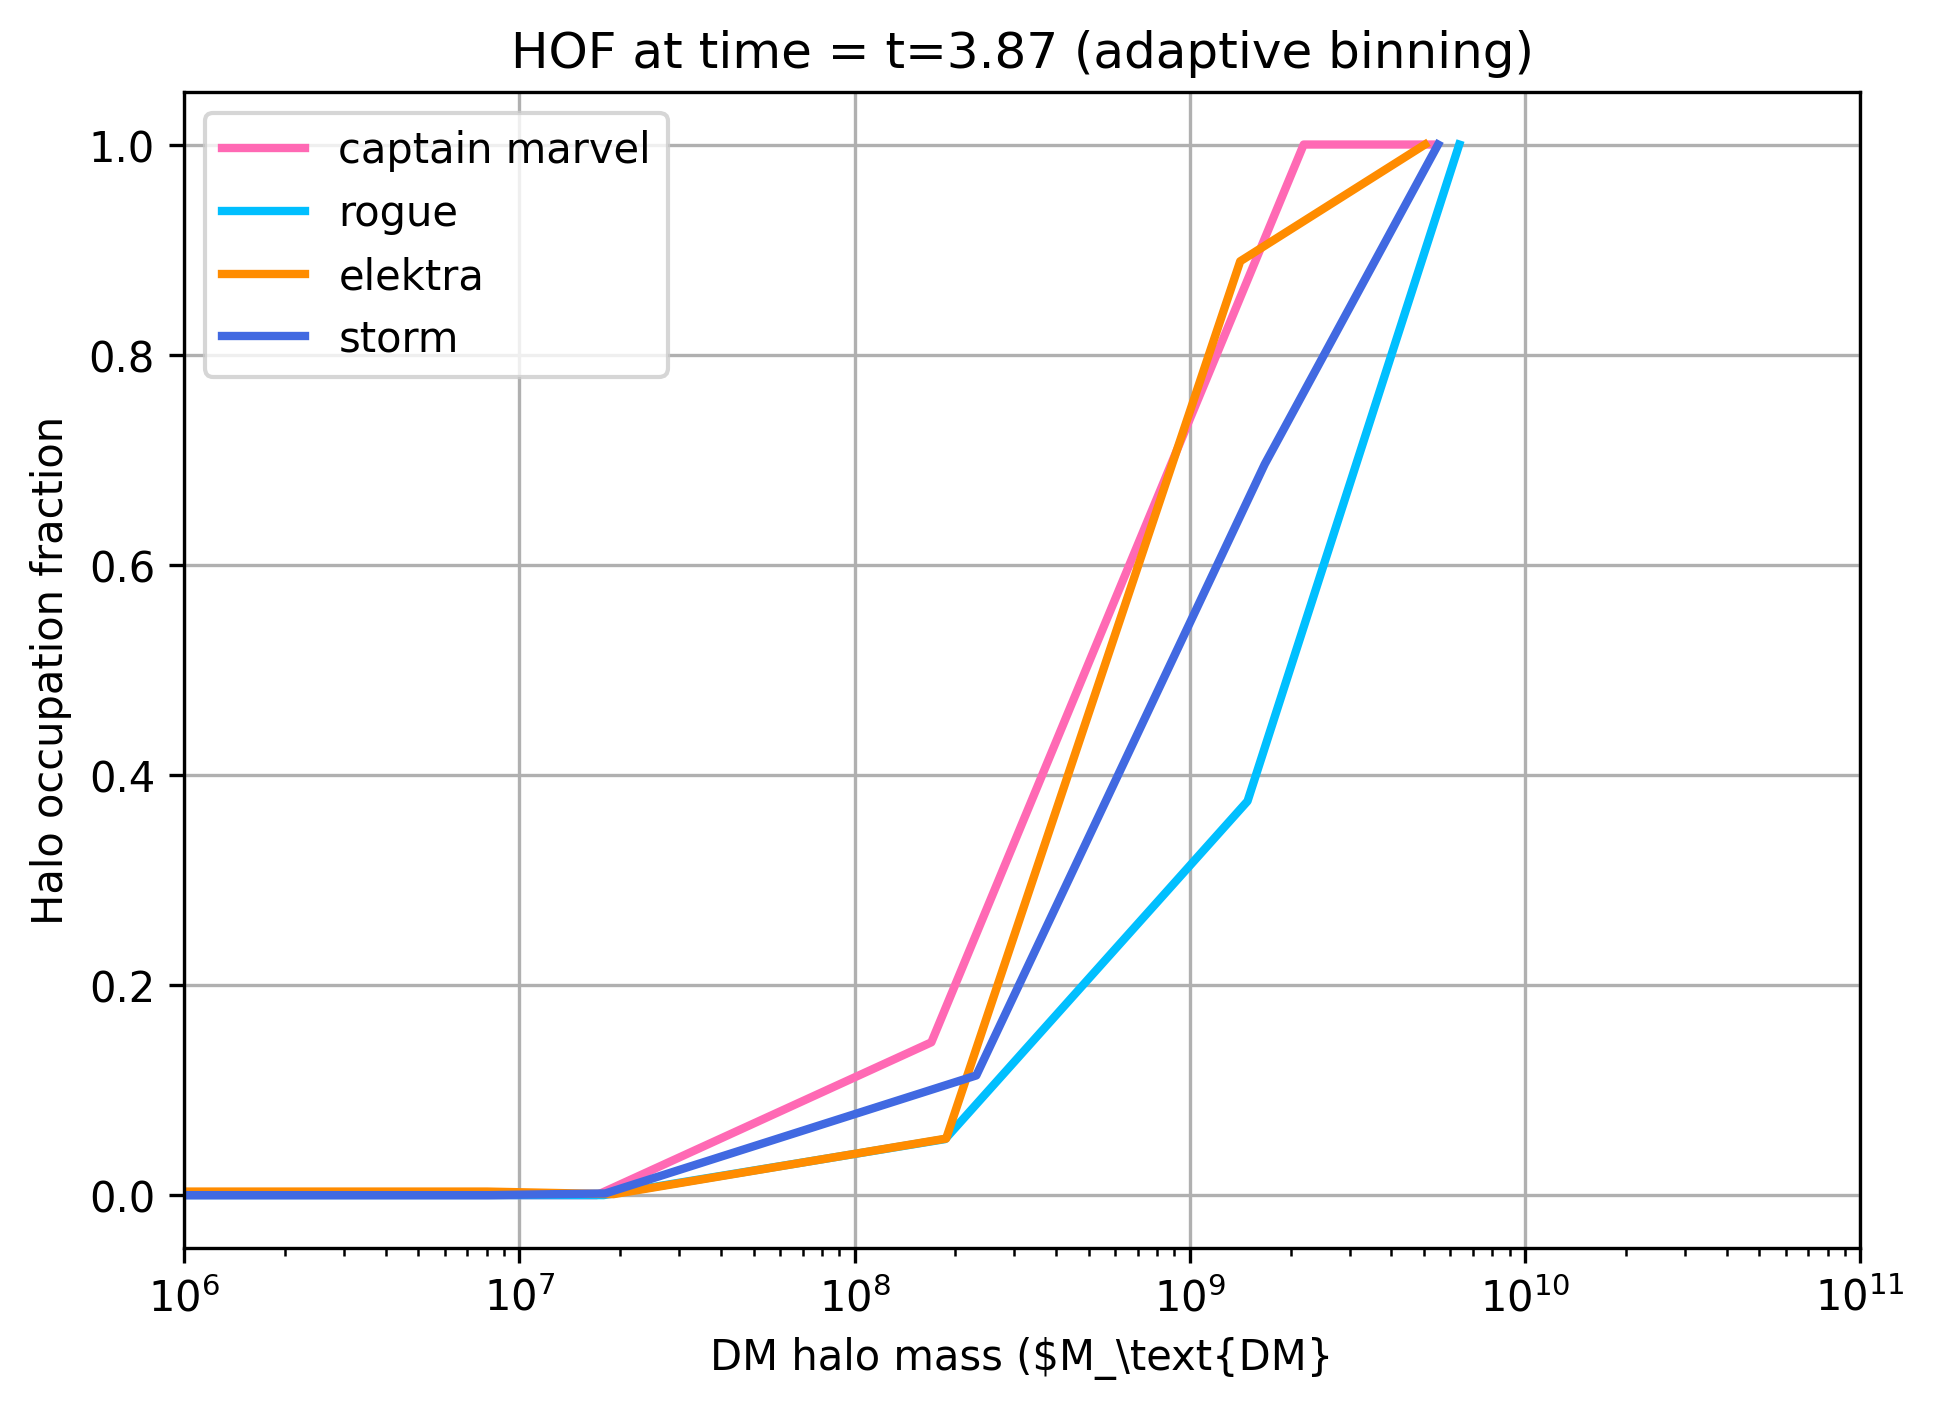

[DM sim 7: bin 1] 0/218 = 0.0
[DM sim 7: bin 2] 1/311 = 0.003215434083601286
[DM sim 7: bin 3] 4/49 = 0.08163265306122448
[DM sim 7: bin 4] 6/6 = 1.0
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 0/645 = 0.0
[DM sim 7: bin 2] 0/1073 = 0.0
[DM sim 7: bin 3] 5/156 = 0.03205128205128205
[DM sim 7: bin 4] 5/17 = 0.29411764705882354
[DM sim 7: bin 5] 6/6 = 1.0
[DM sim 7: bin 1] 1/588 = 0.0017006802721088435
[DM sim 7: bin 2] 1/1113 = 0.0008984725965858042
[DM sim 7: bin 3] 7/144 = 0.04861111111111111
[DM sim 7: bin 4] 7/7 = 1.0
[DM sim 7: bin 5] 6/6 = 1.0
[DM sim 7: bin 1] 0/717 = 0.0
[DM sim 7: bin 2] 2/1234 = 0.0016207455429497568
[DM sim 7: bin 3] 17/165 = 0.10303030303030303
[DM sim 7: bin 4] 13/24 = 0.5416666666666666
[DM sim 7: bin 5] 10/11 = 0.9090909090909091


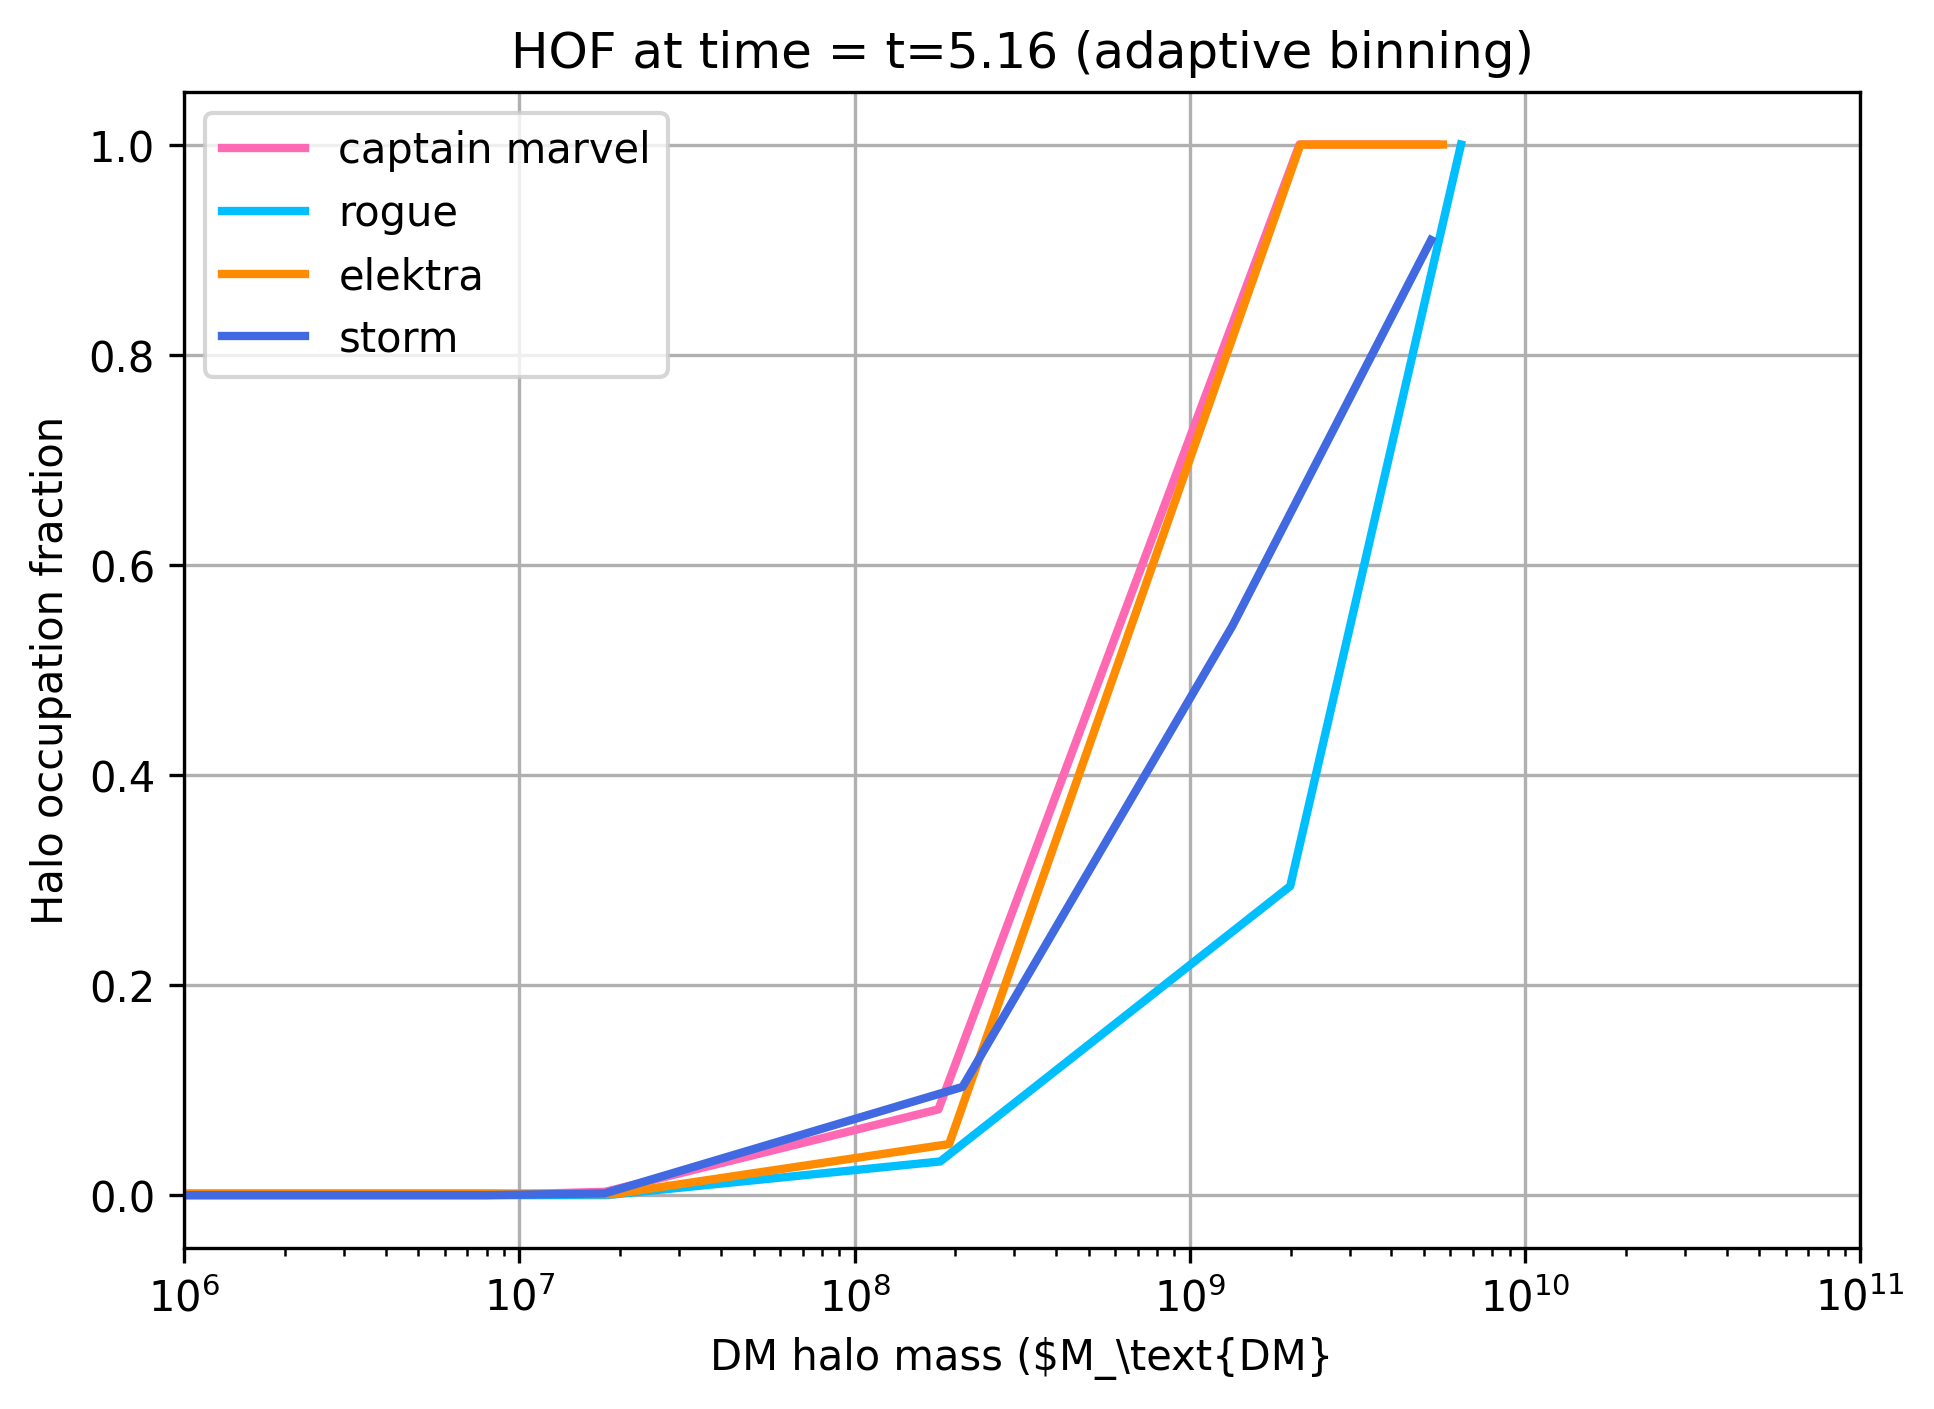

[DM sim 7: bin 1] 0/195 = 0.0
[DM sim 7: bin 2] 1/328 = 0.003048780487804878
[DM sim 7: bin 3] 5/52 = 0.09615384615384616
[DM sim 7: bin 4] 4/4 = 1.0
[DM sim 7: bin 5] 4/4 = 1.0
[DM sim 7: bin 1] 0/632 = 0.0
[DM sim 7: bin 2] 0/1066 = 0.0
[DM sim 7: bin 3] 6/161 = 0.037267080745341616
[DM sim 7: bin 4] 5/19 = 0.2631578947368421
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 5/596 = 0.008389261744966443
[DM sim 7: bin 2] 1/1130 = 0.0008849557522123894
[DM sim 7: bin 3] 5/149 = 0.03355704697986577
[DM sim 7: bin 4] 7/8 = 0.875
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 0/706 = 0.0
[DM sim 7: bin 2] 1/1226 = 0.0008156606851549756
[DM sim 7: bin 3] 14/158 = 0.08860759493670886
[DM sim 7: bin 4] 14/25 = 0.56
[DM sim 7: bin 5] 10/11 = 0.9090909090909091


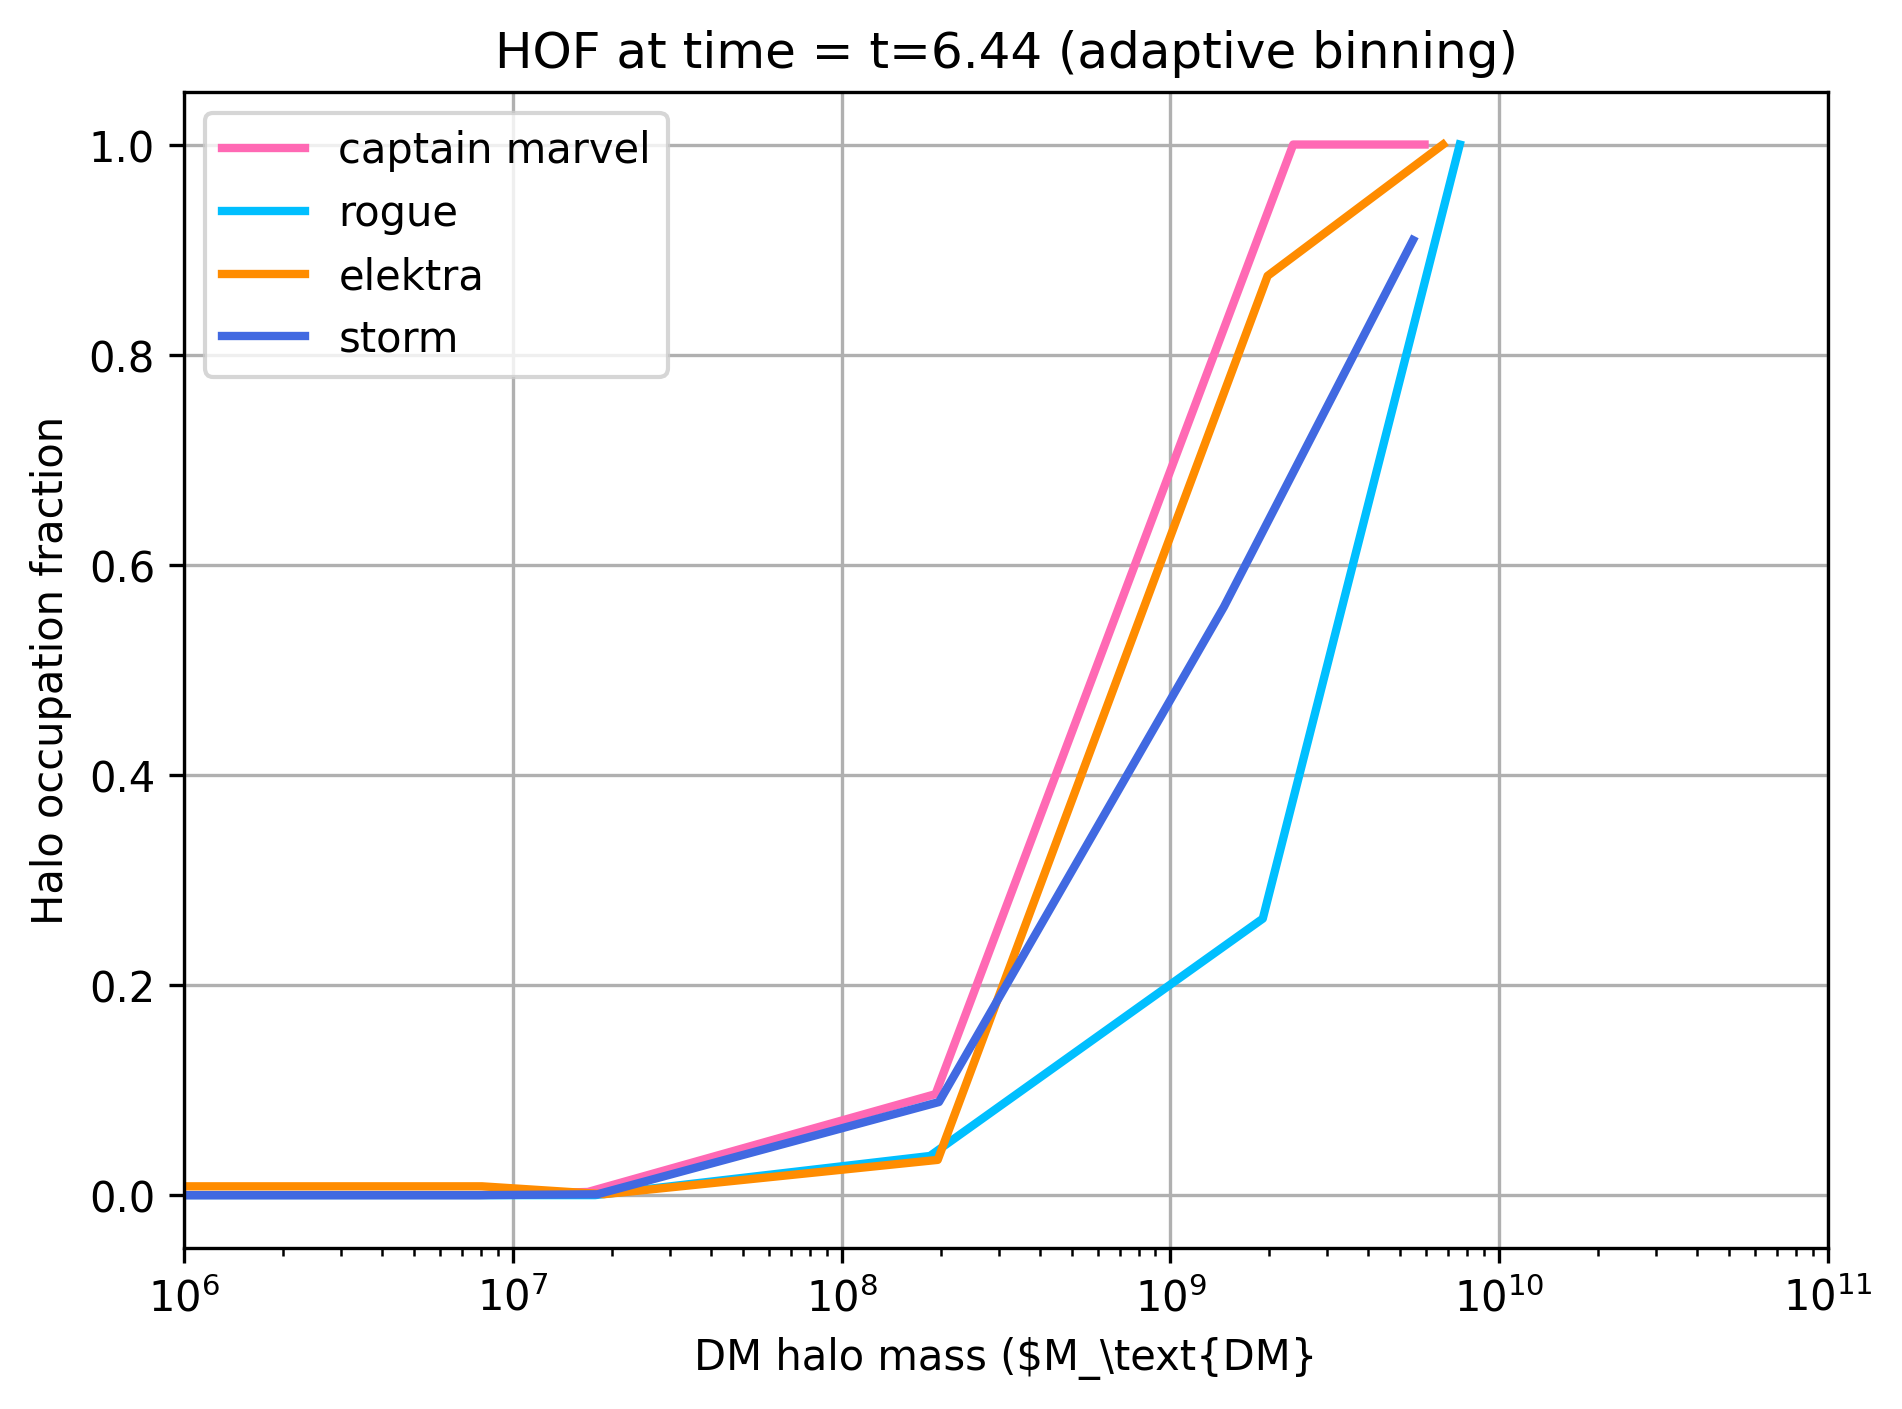

[DM sim 7: bin 1] 0/193 = 0.0
[DM sim 7: bin 2] 2/324 = 0.006172839506172839
[DM sim 7: bin 3] 2/48 = 0.041666666666666664
[DM sim 7: bin 4] 5/5 = 1.0
[DM sim 7: bin 5] 4/4 = 1.0
[DM sim 7: bin 1] 0/611 = 0.0
[DM sim 7: bin 2] 0/1035 = 0.0
[DM sim 7: bin 3] 6/162 = 0.037037037037037035
[DM sim 7: bin 4] 5/19 = 0.2631578947368421
[DM sim 7: bin 5] 3/4 = 0.75
[DM sim 7: bin 1] 3/585 = 0.005128205128205128
[DM sim 7: bin 2] 2/1133 = 0.00176522506619594
[DM sim 7: bin 3] 3/146 = 0.02054794520547945
[DM sim 7: bin 4] 7/10 = 0.7
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 1/682 = 0.001466275659824047
[DM sim 7: bin 2] 1/1190 = 0.0008403361344537816
[DM sim 7: bin 3] 14/155 = 0.09032258064516129
[DM sim 7: bin 4] 16/24 = 0.6666666666666666
[DM sim 7: bin 5] 7/8 = 0.875


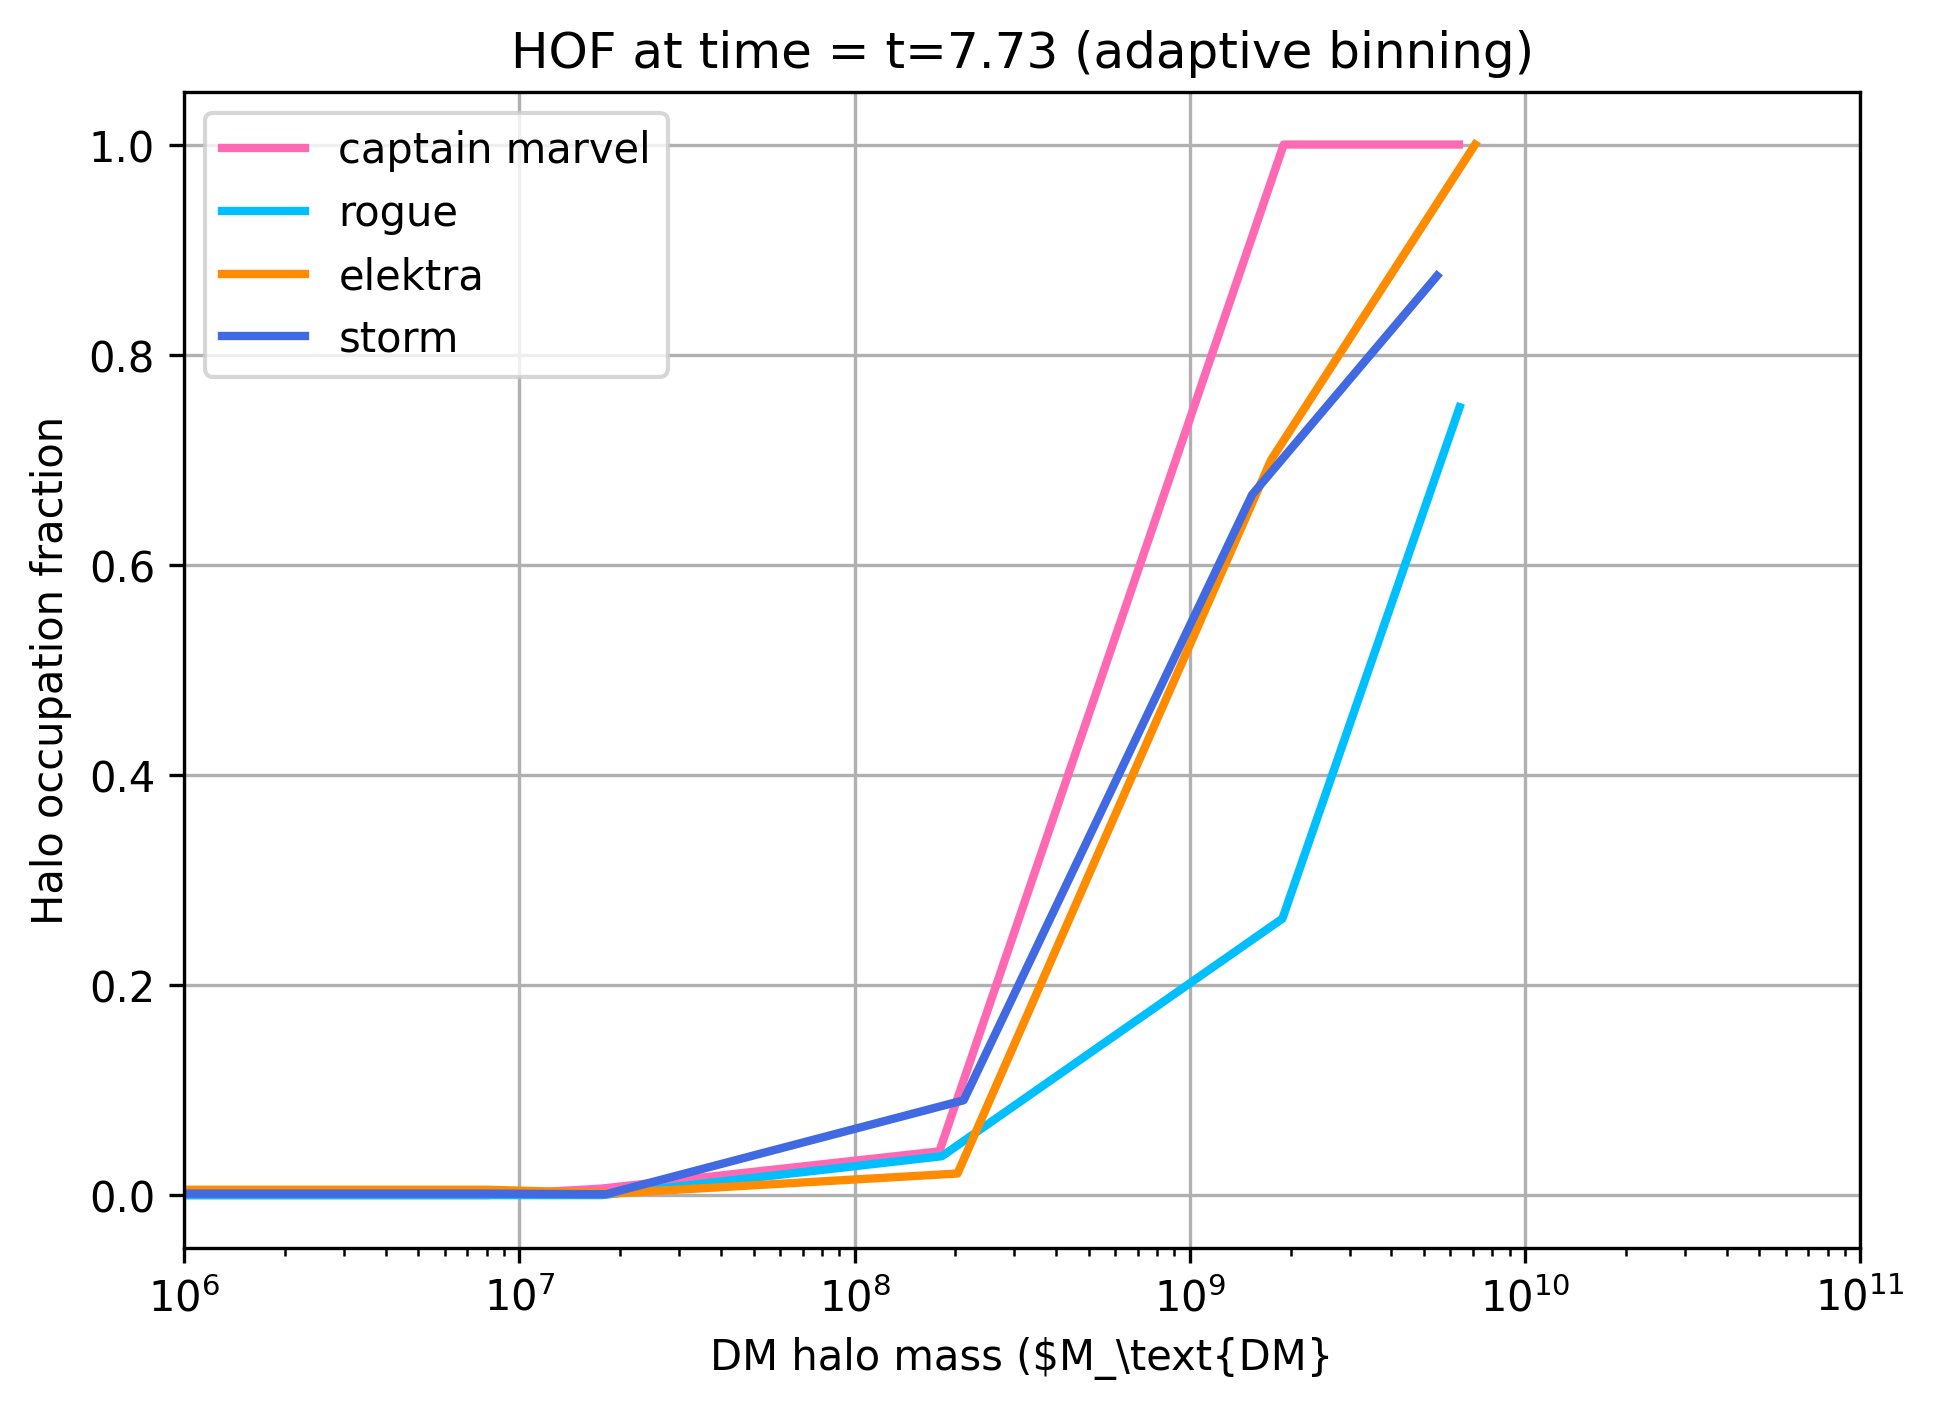

[DM sim 7: bin 1] 0/206 = 0.0
[DM sim 7: bin 2] 2/325 = 0.006153846153846154
[DM sim 7: bin 3] 2/47 = 0.0425531914893617
[DM sim 7: bin 4] 4/4 = 1.0
[DM sim 7: bin 5] 5/5 = 1.0
[DM sim 7: bin 1] 1/610 = 0.001639344262295082
[DM sim 7: bin 2] 1/1015 = 0.0009852216748768472
[DM sim 7: bin 3] 5/158 = 0.03164556962025317
[DM sim 7: bin 4] 3/16 = 0.1875
[DM sim 7: bin 5] 2/3 = 0.6666666666666666
[DM sim 7: bin 1] 3/596 = 0.0050335570469798654
[DM sim 7: bin 2] 1/1118 = 0.0008944543828264759
[DM sim 7: bin 3] 3/148 = 0.02027027027027027
[DM sim 7: bin 4] 7/10 = 0.7
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 2/682 = 0.002932551319648094
[DM sim 7: bin 2] 2/1140 = 0.0017543859649122807
[DM sim 7: bin 3] 14/156 = 0.08974358974358974
[DM sim 7: bin 4] 13/25 = 0.52
[DM sim 7: bin 5] 8/8 = 1.0


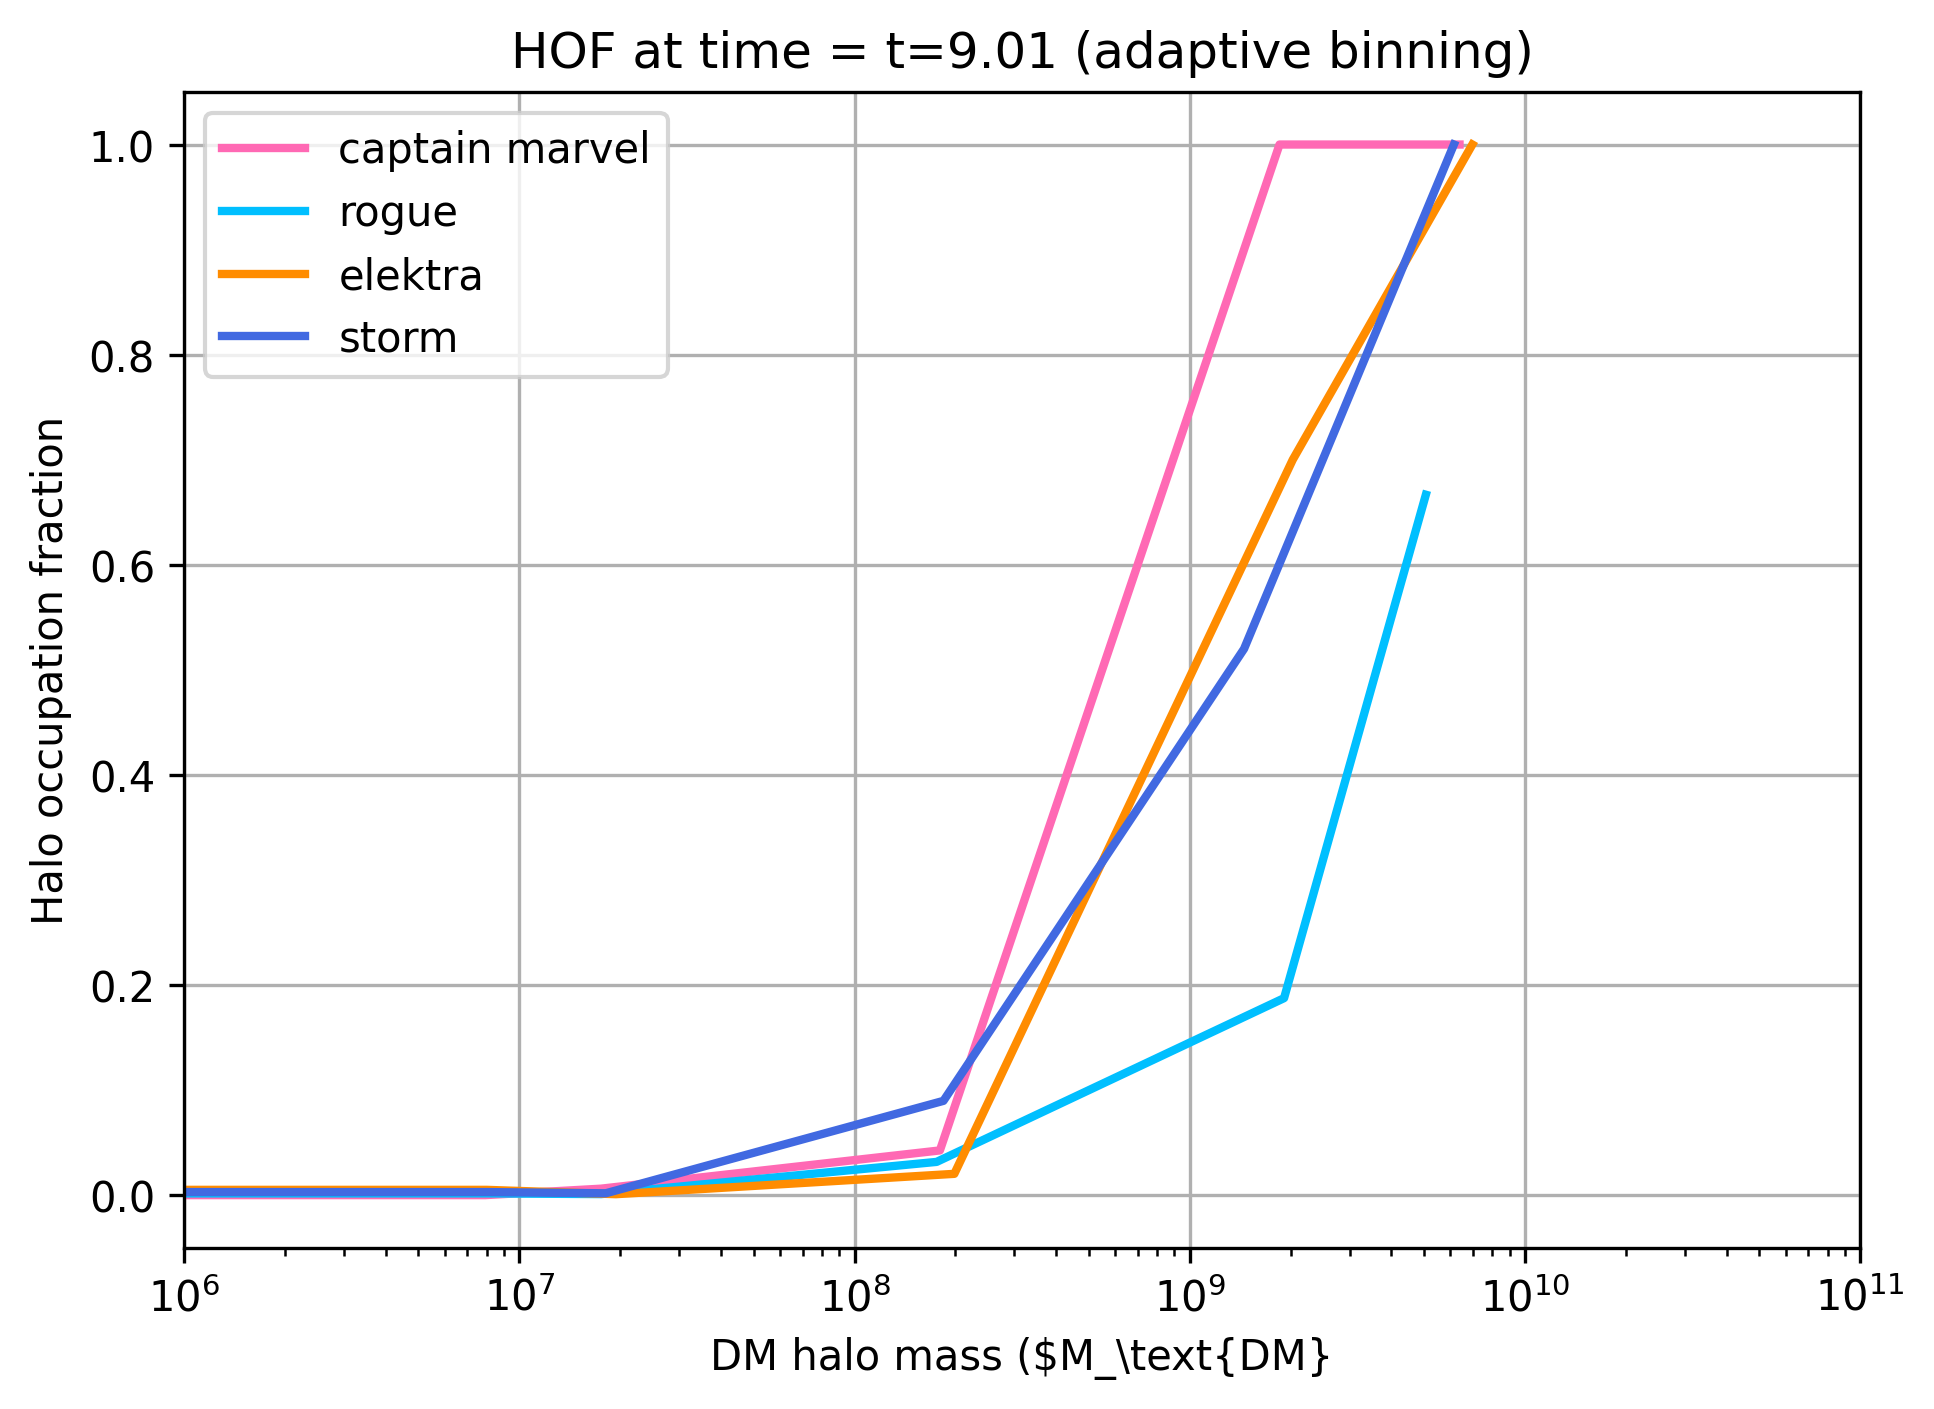

[DM sim 7: bin 1] 0/213 = 0.0
[DM sim 7: bin 2] 2/320 = 0.00625
[DM sim 7: bin 3] 2/43 = 0.046511627906976744
[DM sim 7: bin 4] 4/5 = 0.8
[DM sim 7: bin 5] 5/5 = 1.0
[DM sim 7: bin 1] 0/595 = 0.0
[DM sim 7: bin 2] 0/984 = 0.0
[DM sim 7: bin 3] 5/156 = 0.03205128205128205
[DM sim 7: bin 4] 3/16 = 0.1875
[DM sim 7: bin 5] 1/2 = 0.5
[DM sim 7: bin 1] 1/595 = 0.0016806722689075631
[DM sim 7: bin 2] 1/1121 = 0.0008920606601248885
[DM sim 7: bin 3] 3/144 = 0.020833333333333332
[DM sim 7: bin 4] 7/12 = 0.5833333333333334
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 0/641 = 0.0
[DM sim 7: bin 2] 2/1108 = 0.0018050541516245488
[DM sim 7: bin 3] 15/153 = 0.09803921568627451
[DM sim 7: bin 4] 13/24 = 0.5416666666666666
[DM sim 7: bin 5] 8/8 = 1.0


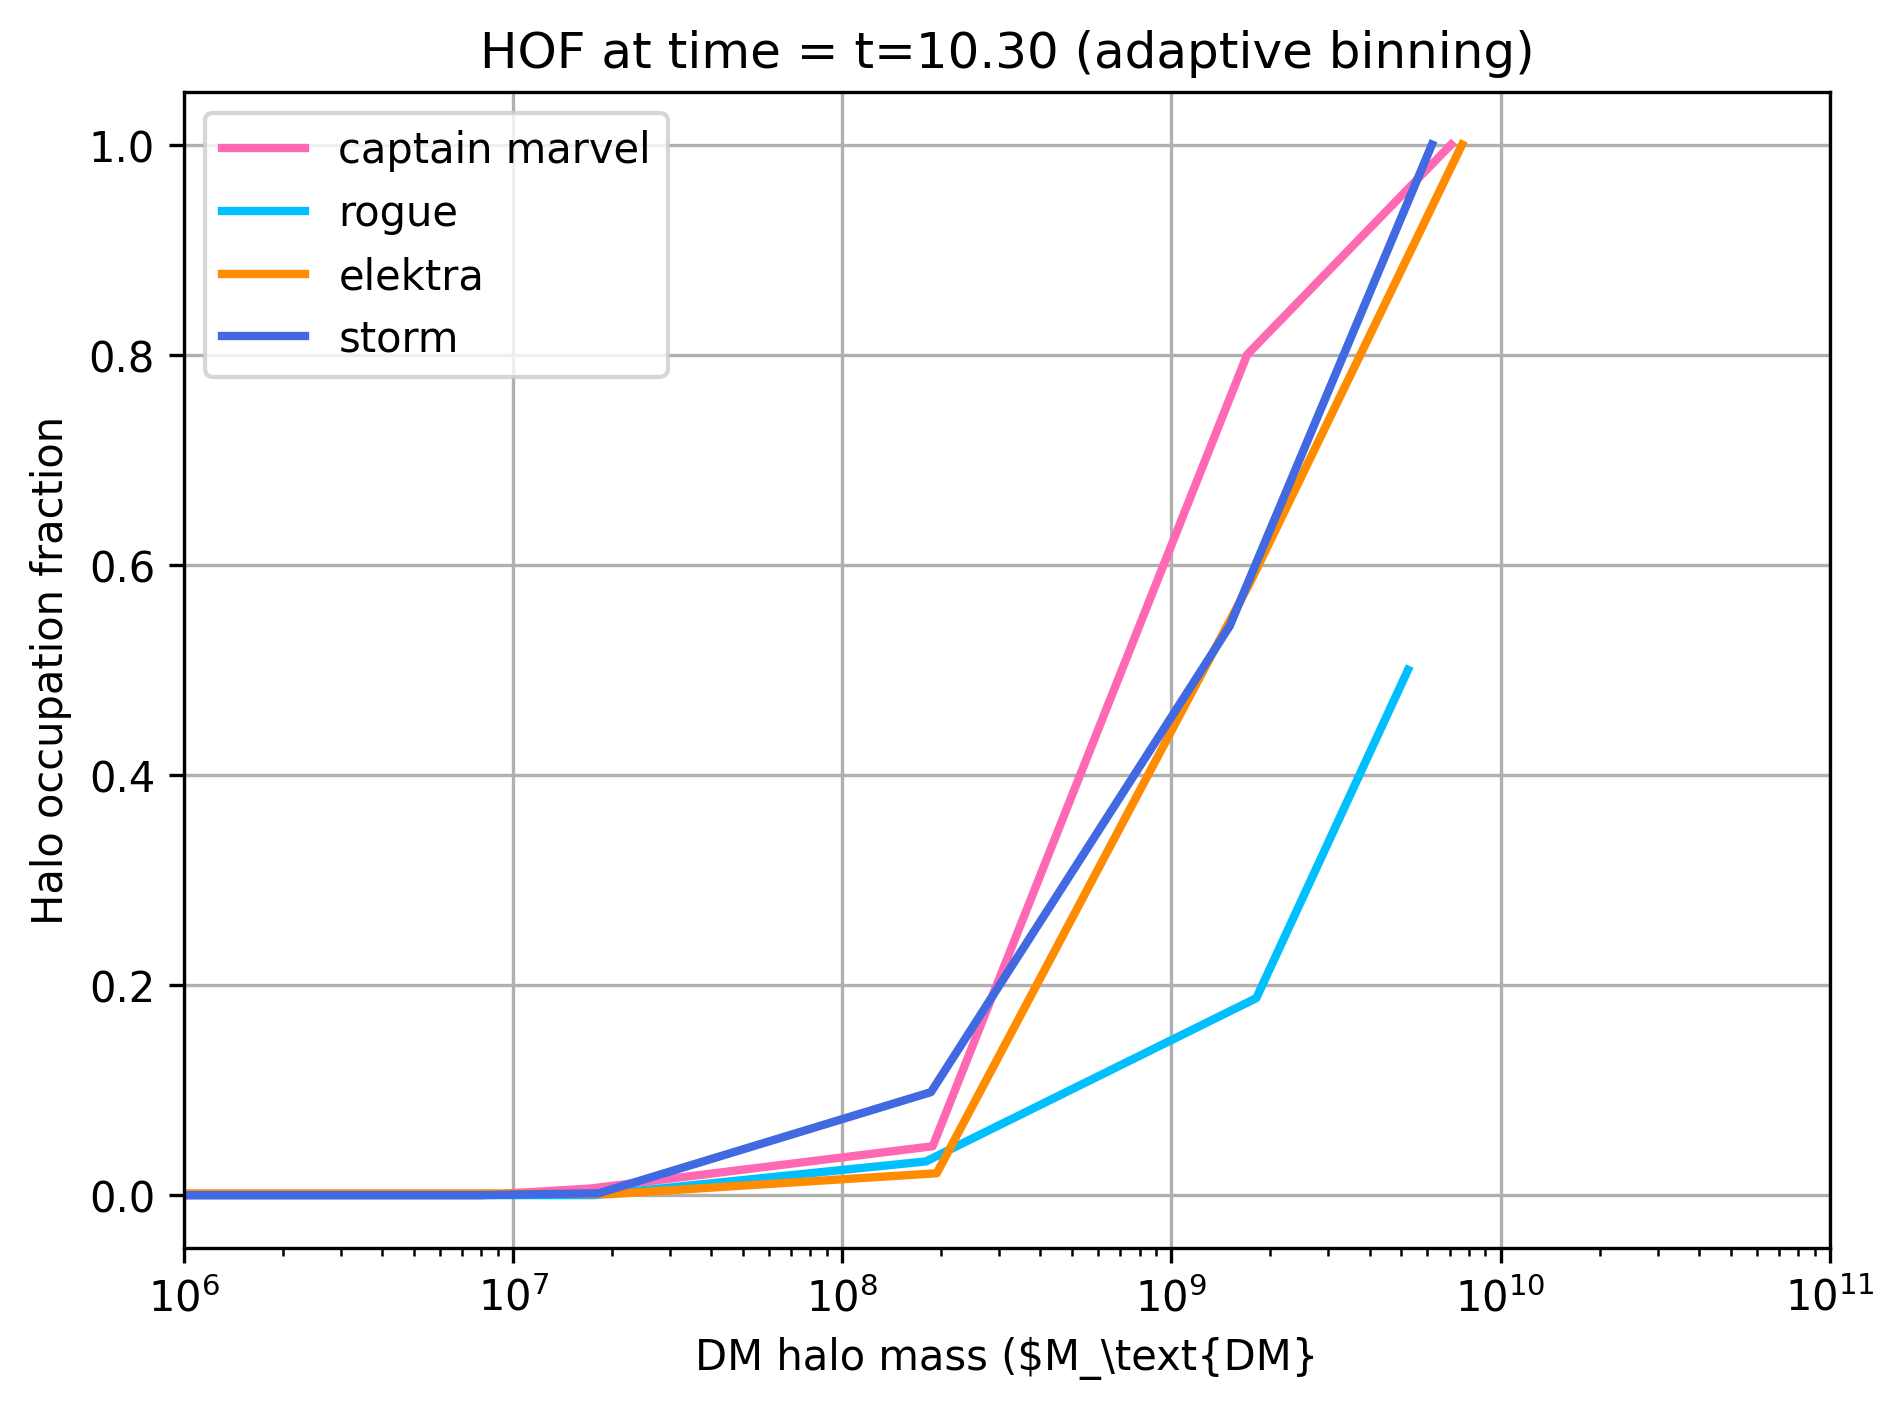

[DM sim 7: bin 1] 0/199 = 0.0
[DM sim 7: bin 2] 3/318 = 0.009433962264150943
[DM sim 7: bin 3] 1/40 = 0.025
[DM sim 7: bin 4] 4/4 = 1.0
[DM sim 7: bin 5] 4/4 = 1.0
[DM sim 7: bin 1] 0/557 = 0.0
[DM sim 7: bin 2] 0/970 = 0.0
[DM sim 7: bin 3] 5/155 = 0.03225806451612903
[DM sim 7: bin 4] 4/15 = 0.26666666666666666
[DM sim 7: bin 5] 1/2 = 0.5
[DM sim 7: bin 1] 1/601 = 0.0016638935108153079
[DM sim 7: bin 2] 0/1108 = 0.0
[DM sim 7: bin 3] 3/147 = 0.02040816326530612
[DM sim 7: bin 4] 7/12 = 0.5833333333333334
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 2/642 = 0.003115264797507788
[DM sim 7: bin 2] 0/1065 = 0.0
[DM sim 7: bin 3] 16/157 = 0.10191082802547771
[DM sim 7: bin 4] 10/21 = 0.47619047619047616
[DM sim 7: bin 5] 8/8 = 1.0


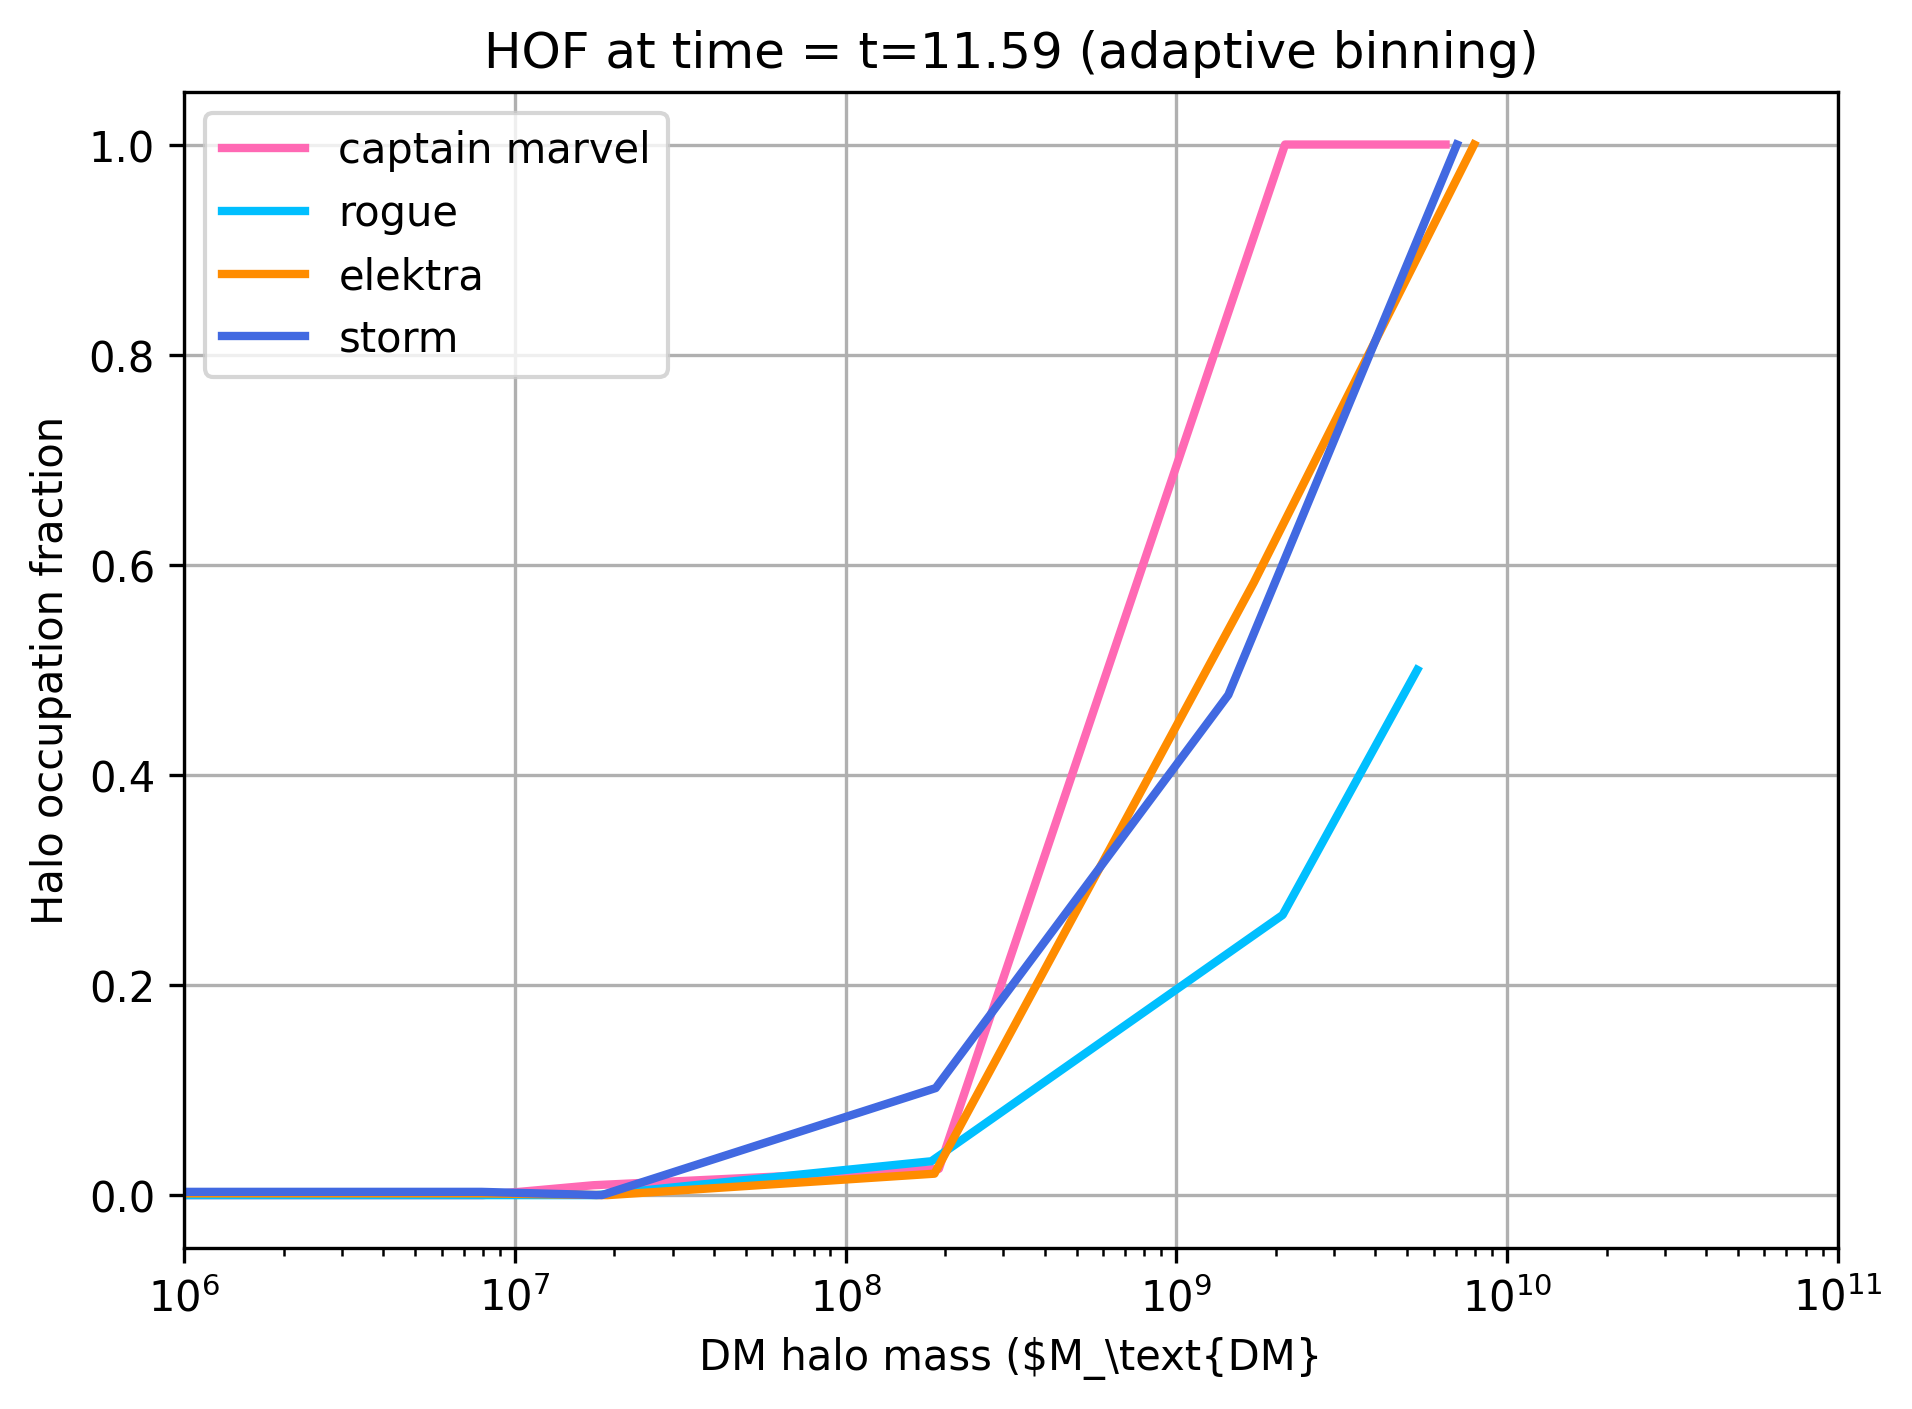

[DM sim 7: bin 1] 0/197 = 0.0
[DM sim 7: bin 2] 2/314 = 0.006369426751592357
[DM sim 7: bin 3] 1/41 = 0.024390243902439025
[DM sim 7: bin 4] 4/4 = 1.0
[DM sim 7: bin 5] 5/5 = 1.0
[DM sim 7: bin 1] 0/534 = 0.0
[DM sim 7: bin 2] 0/962 = 0.0
[DM sim 7: bin 3] 5/155 = 0.03225806451612903
[DM sim 7: bin 4] 3/13 = 0.23076923076923078
[DM sim 7: bin 5] 3/3 = 1.0
[DM sim 7: bin 1] 2/595 = 0.0033613445378151263
[DM sim 7: bin 2] 0/1099 = 0.0
[DM sim 7: bin 3] 3/148 = 0.02027027027027027
[DM sim 7: bin 4] 7/11 = 0.6363636363636364
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 1/647 = 0.0015455950540958269
[DM sim 7: bin 2] 1/1020 = 0.000980392156862745
[DM sim 7: bin 3] 12/151 = 0.07947019867549669
[DM sim 7: bin 4] 10/21 = 0.47619047619047616
[DM sim 7: bin 5] 7/7 = 1.0


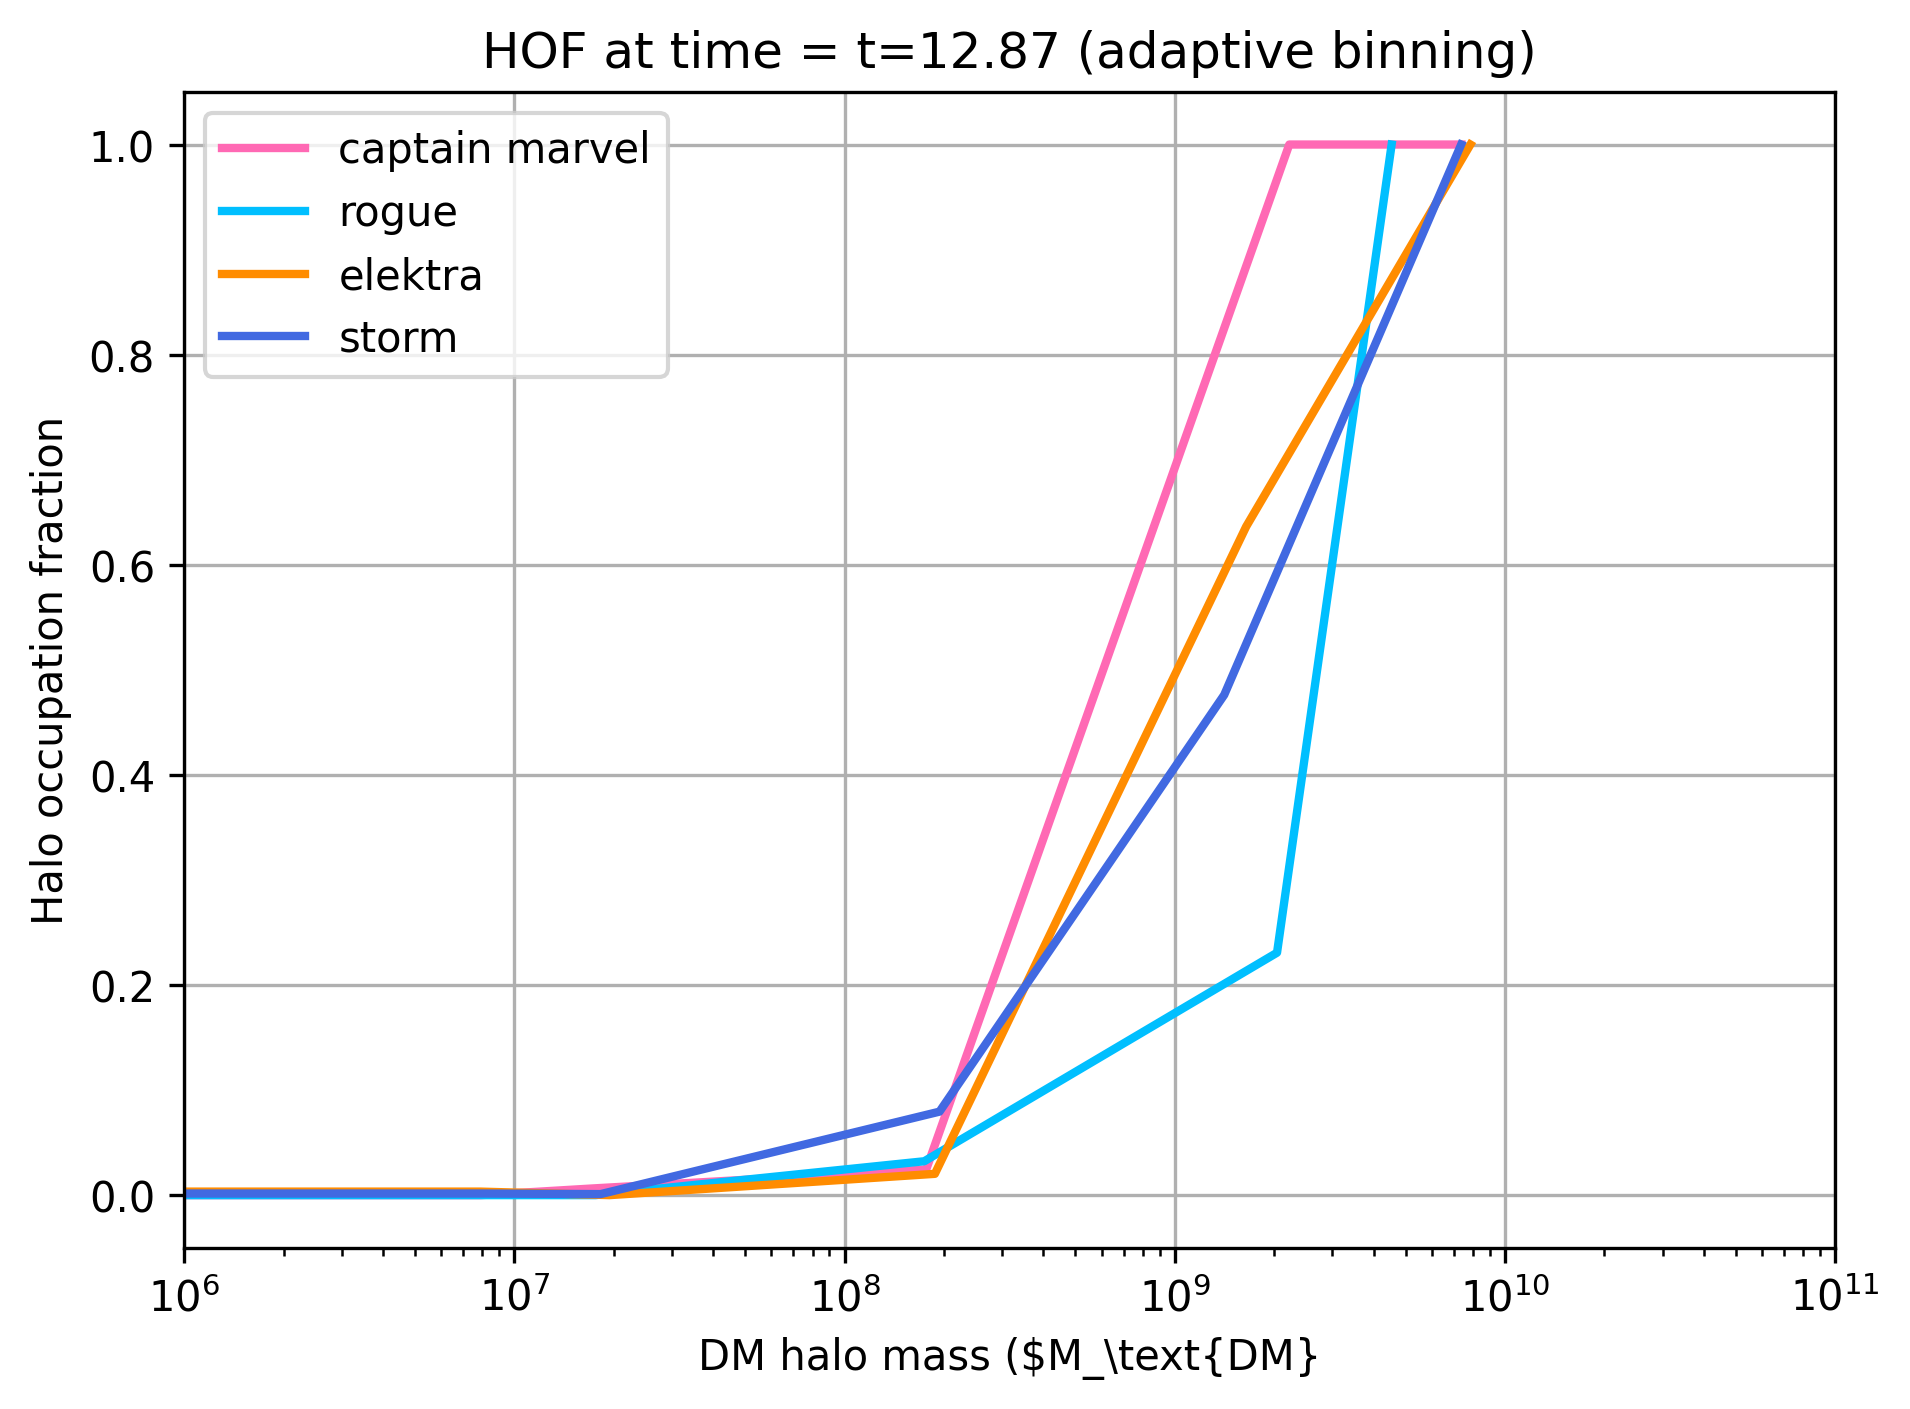

[DM sim 7: bin 1] 0/198 = 0.0
[DM sim 7: bin 2] 2/305 = 0.006557377049180328
[DM sim 7: bin 3] 1/42 = 0.023809523809523808
[DM sim 7: bin 4] 4/4 = 1.0
[DM sim 7: bin 5] 5/5 = 1.0
[DM sim 7: bin 1] 0/520 = 0.0
[DM sim 7: bin 2] 0/955 = 0.0
[DM sim 7: bin 3] 4/150 = 0.02666666666666667
[DM sim 7: bin 4] 5/13 = 0.38461538461538464
[DM sim 7: bin 5] 2/3 = 0.6666666666666666
[DM sim 7: bin 1] 0/583 = 0.0
[DM sim 7: bin 2] 0/1096 = 0.0
[DM sim 7: bin 3] 3/143 = 0.02097902097902098
[DM sim 7: bin 4] 7/12 = 0.5833333333333334
[DM sim 7: bin 5] 2/2 = 1.0
[DM sim 7: bin 1] 1/625 = 0.0016
[DM sim 7: bin 2] 1/1012 = 0.0009881422924901185
[DM sim 7: bin 3] 12/147 = 0.08163265306122448
[DM sim 7: bin 4] 9/20 = 0.45
[DM sim 7: bin 5] 7/7 = 1.0


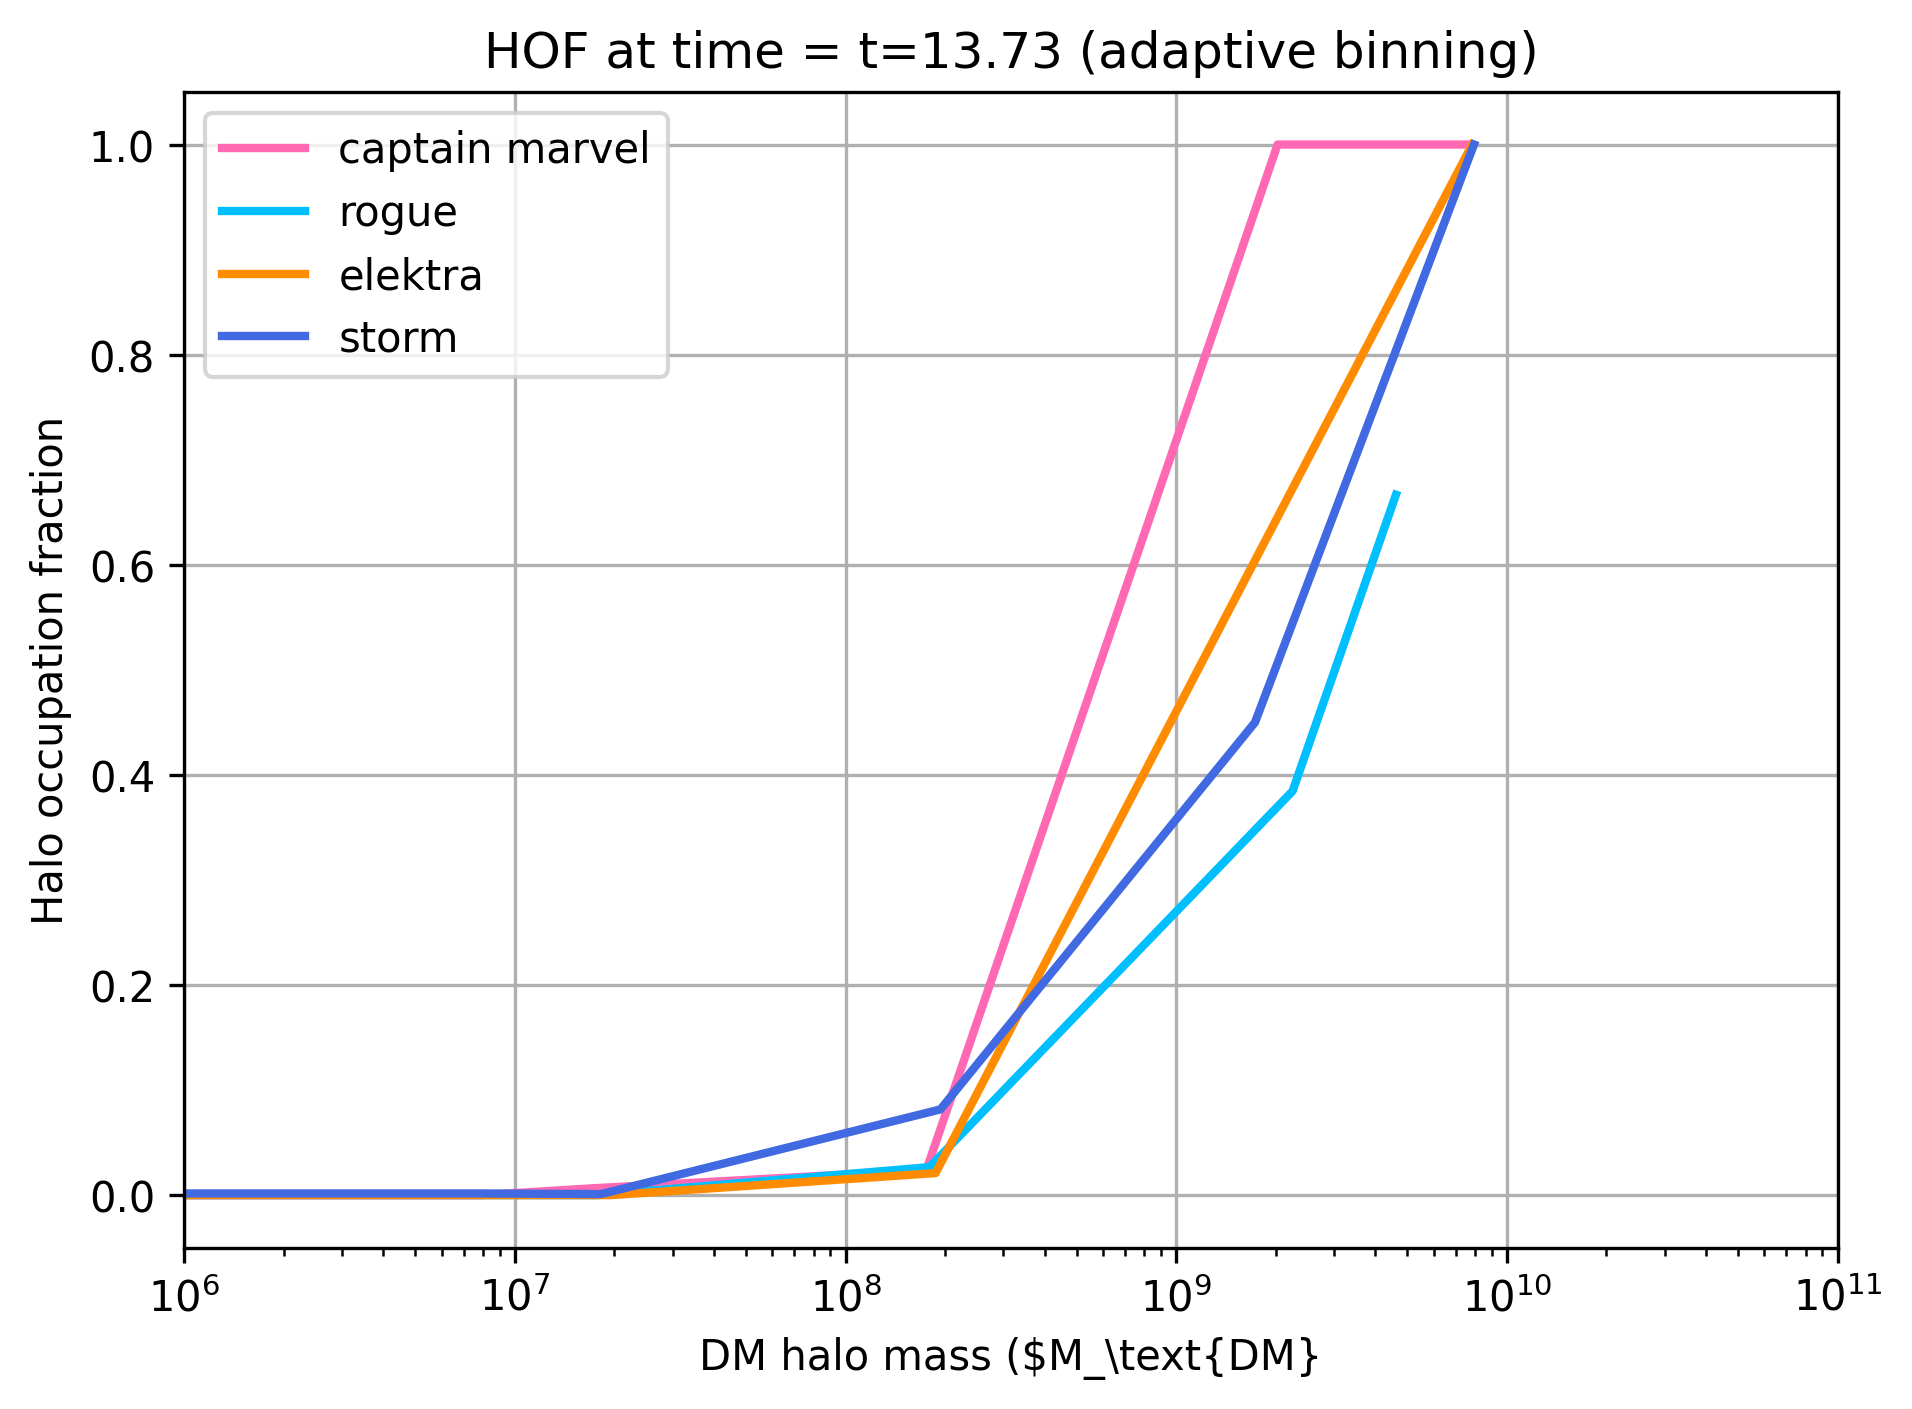

In [10]:
# HOF over time for Marvel sims using time grouping made by Anwar + discrete binning
"""
Cummulative HOF at all redshifts
Sims: Marvel partial_DB files
Adaptive binning
4/28/25
"""

sim_names = ['cptmarvel', 'rogue', 'elektra', 'storm']
times = ['t=2.26', 't=2.58', 't=3.87', 't=5.16', 't=6.44', 't=7.73', 't=9.01', 't=10.30', 't=11.59', 't=12.87', 't=13.73']
n_sims = 4
n_timesteps = len(times)

# make plots
colors = np.array(['hotpink', 'deepskyblue', 'darkorange', 'royalblue'])
labels = np.array(['captain marvel', 'rogue', 'elektra', 'storm'])

# bins for plotting
bins = np.array([1e5,1e7,1e8,1e9,4e9,1e10])

zip_path = 'HOF_time_grouped.zip'

with zipfile.ZipFile(zip_path, 'r') as zipf:
    all_files = zipf.namelist()
    
    # get data at each redshift
    for t in range(n_timesteps):
    
        directory = f'HOF_time_grouped/{times[t]}/'
        files_in_t = [f for f in all_files if f.startswith(directory) and f.endswith('.txt')]
    
        plt.figure(dpi = 300)
        sim_num = 0
        
        # loop through each simulation at redshift z
        for file in files_in_t:
    
            with zipf.open(file) as f:
            
                data = np.genfromtxt(f, skip_header = 1, dtype=float, encoding='utf-8')
    
            # get and sort data
            masses = data[:,1]
            Nstars = data[:,2]
        
            occ_frac_data, DM_mass_data = discrete_HOF(masses,Nstars,bins)
            
        
            plt.semilogx(DM_mass_data, occ_frac_data, linestyle='-', linewidth = 2, color = colors[sim_num], label = labels[sim_num])
    
            sim_num += 1 
    
        plt.xlabel(r'DM halo mass ($M_\text{DM}')
        plt.ylabel('Halo occupation fraction')
        plt.title(f"HOF at time = {times[t]}")
        plt.grid(True)
        plt.tight_layout()
        plt.legend()
        plt.xlim(1e6,1e11)
        plt.show()
    



In [ ]:
# Models from Nadler 2025 for comparison to HOF plots 
"""
Models code
NGM23 and BF20
6/5/25
"""
# import NGM23 and BF20 fits
NGM23 = np.loadtxt('Stat_Files/NGM23_fit.csv', delimiter = ',')
BF20 = np.loadtxt('Stat_Files/BF20_fit.csv', delimiter = ',')

# define DM_mass arrays and HOf arrays
NGM23_DM_mass = 10 ** NGM23[:,0]
NGM23_HOF = NGM23[:,1]

BF20_DM_mass = 10 ** BF20[:,0]
BF20_HOF = BF20[:,1]

plt.semilogx(NGM23_DM_mass, NGM23_HOF, linestyle='dashed', linewidth = 2, color = 'k', label = 'NGM23 fit (with H2 cooling)')
plt.plot(BF20_DM_mass, BF20_HOF, linestyle='dotted', linewidth = 2, color = 'k', label = 'BF20 fit (without H2 cooling)')
